<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/10_threshold_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB10 — Diagnóstico Metodológico de Limiar, Granularidade, K/H e Persistência Mínima

## 1. Contexto

Este notebook inicia o refinamento metodológico do ciclo Kaggle no pipeline experimental da dissertação.

Os notebooks NB00 a NB09 registram o protótipo Kaggle associado ao artigo submetido à SBPO 2026. Esse estágio permanece preservado como referência metodológica e reprodutível, sem renumeração nem alteração retroativa dos resultados utilizados no artigo.

O NB10 estabelece o protótipo Kaggle refinado e realiza a seleção experimental de cenários para a dissertação. Sua função é avaliar, de forma controlada e documentada, quais configurações de limiar, granularidade temporal, região pré-crítica, horizonte de antecipação e persistência mínima são cientificamente adequadas para avançar aos notebooks seguintes.

No artigo, o limiar global retrospectivo foi mantido como critério experimental reprodutível. Para a dissertação, entretanto, é necessário construir cenários mais compatíveis com uma formulação preditiva causal, em que os parâmetros do limiar sejam estimados apenas sobre o trecho de treino ou sobre uma região histórica anterior, sendo depois aplicados ao trecho futuro.

## 2. Objetivo

O objetivo deste notebook é:

1. carregar a série temporal agregada em janelas de 5 minutos;
2. reconstruir, a partir dela, uma série agregada em janelas de 10 minutos;
3. definir previamente o particionamento temporal treino/teste em cada granularidade;
4. calcular o limiar global retrospectivo usado como referência retrospectiva do protótipo Kaggle;
5. calcular o limiar causal `train-only μ + 2σ`;
6. calcular o limiar alternativo `train-only p95`;
7. calcular o limiar extremo `train-only p99` apenas como diagnóstico de severidade;
8. aplicar os limiares ao trecho futuro sem usar estatísticas do teste;
9. diagnosticar empiricamente a distribuição da `fail_rate`;
10. avaliar cenários com janelas de 5 e 10 minutos;
11. avaliar combinações de K/H equivalentes a 120/60 e 60/30 minutos;
12. incluir cenários adicionais que isolam o efeito do horizonte H;
13. avaliar persistência mínima de 1, 2 e 3 janelas contíguas;
14. medir o impacto sobre janelas críticas, episódios, duração, estados e rótulos supervisionados;
15. documentar quais cenários avançam para o NB11;
16. documentar quais cenários ficam apenas como sensibilidade;
17. documentar quais cenários não avançam e por qual motivo científico;
18. salvar artefatos CSV, Parquet, figuras e JSON de rastreabilidade.

## 3. Papel no Pipeline Atualizado

O NB10 não substitui o artigo e não invalida os notebooks NB00 a NB09.

Seu papel é separar quatro níveis de análise:

1. **protótipo Kaggle**: limiar global retrospectivo, janela de 5 minutos, K=24, H=12 e persistência mínima equivalente a 1 janela;
2. **protótipo Kaggle refinado**: limiares estimados exclusivamente no treino e aplicados ao futuro;
3. **linha de sensibilidade operacional**: variação de granularidade temporal, K/H e persistência mínima;
4. **linha de descarte metodológico**: cenários excessivamente raros, excessivamente sensíveis ou pouco adequados à decisão sob incerteza.

Com isso, o pipeline passa a distinguir entre:

1. o que pertence ao protótipo Kaggle utilizado no artigo submetido;
2. o que será tratado como cenário principal da dissertação;
3. o que será tratado como sensibilidade metodológica;
4. o que será descartado para evitar explosão combinatória;
5. quais deltas precisam ser explicados no texto final;
6. quais artefatos passam a orientar NB11, NB12, NB13, NB14, NB15 e NB16.

## 4. Relação com o Artigo SBPO 2026

O artigo formulou o problema como antecipação da entrada em estado crítico em um horizonte futuro, usando séries temporais derivadas de logs, taxa de falha, episódios críticos, estados operacionais e atributos temporais causais.

Nesse contexto, a `fail_rate` é definida como:

$$
fail\_rate_t =
\frac{n\_failed_t}{n\_events_t}
$$

com a convenção:

$$
fail\_rate_t = 0, \quad \text{quando } n\_events_t = 0
$$

No artigo, uma janela foi considerada crítica quando:

$$
fail\_rate_t \geq \mu + 2\sigma
$$

em que $\mu$ e $\sigma$ representam, respectivamente, a média e o desvio-padrão da série agregada.

Esse critério é útil para análise retrospectiva, mas utiliza informação do futuro quando interpretado como regra de decisão preditiva. Por isso, o NB10 mantém esse cenário global apenas como referência comparativa e introduz cenários `train-only`, mais adequados à dissertação.

## 5. Limiar Causal, Percentis e Severidade Extrema

A dissertação deve considerar como cenário metodologicamente mais adequado aquele em que o limiar é estimado sem acesso ao trecho futuro.

Neste notebook são avaliados quatro critérios:

| Cenário | Descrição | Papel |
|---|---|---|
| `global_m2s` | Limiar $\mu + 2\sigma$ calculado sobre toda a série | Referência retrospectiva do artigo |
| `train_m2s` | Limiar $\mu + 2\sigma$ calculado apenas no treino | Candidato principal da dissertação |
| `train_p95` | Percentil 95 calculado apenas no treino | Sensibilidade essencial a assimetria e caudas |
| `train_p99` | Percentil 99 calculado apenas no treino | Diagnóstico de severidade extrema |

O cenário `train_m2s` corrige o uso de informação futura na estimação do limiar. O cenário `train_p95` é incluído porque a distribuição da `fail_rate` pode ser assimétrica, concentrada em zeros ou apresentar caudas pesadas. O cenário `train_p99` não é candidato principal: ele é usado apenas para avaliar o comportamento de eventos extremos e tende a reduzir excessivamente a base positiva.

## 6. Granularidade Temporal

Este notebook avalia duas granularidades:

| Janela | Papel |
|---|---|
| 5 minutos | Cenário de continuidade com o artigo e maior resolução temporal |
| 10 minutos | Cenário operacional mais suavizado e potencialmente menos sensível a ruído |

A série de 10 minutos será reconstruída a partir da série de 5 minutos por agregação de contadores, não por média simples da `fail_rate`.

Assim:

$$
fail\_rate_{10min} =
\frac{\sum n\_failed}{\sum n\_events}
$$

Essa escolha preserva a interpretação estatística da taxa de falha.

## 7. Cenários K/H

Serão avaliados cenários equivalentes em tempo real, não apenas em número de janelas.

| Grupo | Janela | K | H | Interpretação |
|---|---:|---:|---:|---|
| `W5_K24_H12` | 5 min | 24 | 12 | BEFORE/AFTER de 120 min; horizonte de 60 min |
| `W5_K12_H6` | 5 min | 12 | 6 | BEFORE/AFTER de 60 min; horizonte de 30 min |
| `W5_K24_H6` | 5 min | 24 | 6 | BEFORE/AFTER de 120 min; horizonte de 30 min |
| `W10_K12_H6` | 10 min | 12 | 6 | BEFORE/AFTER de 120 min; horizonte de 60 min |
| `W10_K6_H3` | 10 min | 6 | 3 | BEFORE/AFTER de 60 min; horizonte de 30 min |
| `W10_K12_H3` | 10 min | 12 | 3 | BEFORE/AFTER de 120 min; horizonte de 30 min |

Os cenários `W5_K24_H6` e `W10_K12_H3` são incluídos para isolar o efeito do horizonte H, mantendo a mesma região candidata K.

## 8. Persistência Mínima do Episódio Crítico

Este notebook avalia o critério de persistência mínima do episódio crítico.

Esse critério define quantas janelas contíguas acima do limiar são necessárias para que uma sequência seja tratada como episódio crítico válido.

Serão avaliados:

| Persistência mínima | Interpretação |
|---|---|
| 1 janela | Criticidade pontual; máxima comparabilidade com o artigo |
| 2 janelas | Criticidade sustentada; foco operacional preferencial |
| 3 janelas | Criticidade mais restritiva; sensibilidade de severidade |

A continuidade do pipeline deve focalizar principalmente persistências 1 e 2. A persistência 3 será avaliada, mas tende a ser tratada como sensibilidade ou descarte se reduzir excessivamente episódios e positivos.

## 9. Estados Operacionais e Rótulo Supervisionado

Para cada cenário, os episódios críticos são usados para reconstruir os estados operacionais:

$$
S = \{NORMAL, BEFORE, DURING, AFTER\}
$$

A precedência adotada é:

$$
DURING \succ BEFORE \succ AFTER \succ NORMAL
$$

O estado `DURING` corresponde às janelas do episódio crítico. O estado `BEFORE` representa a região anterior ao episódio, definida pelo parâmetro K. O estado `AFTER` representa a região posterior ao episódio, também definida por K.

A variável alvo supervisionada é definida como:

$$
y_t =
\begin{cases}
1, & \text{se existe } t' \in (t, t+H] \text{ tal que } S_{t'} = DURING \\
0, & \text{caso contrário}
\end{cases}
$$

A base supervisionada é restrita a janelas em estado `NORMAL` ou `BEFORE`, com horizonte futuro completo.

## 10. Critérios Científicos para Avançar ou Não Avançar

Este notebook não tem apenas papel diagnóstico. Ele também define, de forma experimental e justificada, quais cenários serão promovidos aos notebooks seguintes da dissertação.

A seleção dos cenários não será baseada apenas em coerência com o artigo, mas nos seguintes critérios científicos:

1. **Quantidade suficiente de episódios**: evitar cenários excessivamente raros.
2. **Taxa positiva supervisionada avaliável**: evitar taxas muito altas ou muito baixas.
3. **Persistência operacional**: privilegiar episódios sustentados sem destruir a base.
4. **Estabilidade temporal**: observar diferenças entre treino e teste.
5. **Interpretação operacional**: priorizar horizontes de 30 e 60 minutos.
6. **Comparabilidade**: manter pelo menos um cenário aderente ao artigo.
7. **Robustez**: evitar cenários excessivamente sensíveis a ruído.
8. **Complexidade**: evitar explosão combinatória do pipeline.
9. **Decisão sob incerteza**: favorecer cenários que possam subsidiar políticas de intervenção.
10. **Rastreabilidade**: registrar a justificativa de avanço, sensibilidade ou descarte em artefato próprio.

As categorias de decisão serão:

| Categoria | Significado |
|---|---|
| `advance_to_nb11` | Cenário promovido para modelagem, baselines, lead time e calibração |
| `sensitivity_only` | Cenário mantido apenas para análise de robustez |
| `do_not_advance` | Cenário descartado do pipeline principal |
| `historical_reference` | Cenário mantido apenas como referência do artigo |


## 11. Contrato de Atributos para os Consumidores Downstream

A contagem de falhas possui duas representações equivalentes nos artefatos de origem: `n_failed` e `event_FAIL_count`. A primeira é adotada como representação única nos vetores preditores. A segunda permanece nos dados model-facing apenas para proveniência, conferência de esquema e auditoria.

Os conjuntos ativos são:

```python
raw_core = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

temporal_core = raw_core + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
```

Assim, `raw_core` contém 6 atributos e `temporal_core` contém 13. A denominação `raw_7` não integra a linhagem ativa. O NB10 registra esse contrato para o NB11 e verifica, antes da materialização dos cenários, a igualdade entre `n_failed` e `event_FAIL_count`, a cardinalidade dos conjuntos, a unicidade dos nomes e a ausência da coluna de proveniência nos preditores.

`fail_rate`, `n_events` e `n_failed` permanecem semanticamente inalterados. A relação determinística usada na formulação continua sendo:

\[
fail\_rate_t = \frac{n\_failed_t}{n\_events_t},
\]

com valor zero quando `n_events = 0`. A correção elimina apenas a duplicação exata da contagem de falhas no vetor de entrada; não remove colunas dos Parquets nem cria variável substituta.


## 12. Entradas Esperadas

Este notebook utiliza como entrada principal a série temporal agregada em janelas de 5 minutos, preferencialmente:

| Arquivo | Finalidade |
|---|---|
| `window_5min_series.parquet` | Série temporal contínua agregada em janelas de 5 minutos |
| `window_5min_series_scored.parquet` | Alternativa, caso a série já contenha marcações anteriores |
| `window_5min_features.parquet` | Alternativa de contingência, se contiver `fail_rate` e `bucket_id` |
| `window_5min_labeled.parquet` | Alternativa final, caso os arquivos anteriores não estejam disponíveis |

A entrada mínima deve conter:

1. `bucket_id`;
2. `fail_rate`;
3. preferencialmente `n_events` e `n_failed`.

## 13. Figuras Esperadas

Ao final deste notebook, espera-se gerar:

| Figura | Arquivo |
|---|---|
| Histograma da `fail_rate` em 5 min com limiares | `fig_01_w5_fail_rate_hist_thresholds.png` |
| Histograma da `fail_rate` em 10 min com limiares | `fig_02_w10_fail_rate_hist_thresholds.png` |
| Série temporal em 5 min com limiares e corte treino/teste | `fig_03_w5_fail_rate_time_thresholds.png` |
| Série temporal em 10 min com limiares e corte treino/teste | `fig_04_w10_fail_rate_time_thresholds.png` |
| Episódios por cenário principal | `fig_05_main_scenarios_episodes.png` |
| Taxa positiva por cenário principal | `fig_06_main_scenarios_positive_rate.png` |
| Decisão metodológica por categoria | `fig_07_scenario_decision_categories.png` |

## 14. Saídas Esperadas

Ao final deste notebook, espera-se obter:

| Artefato | Finalidade |
|---|---|
| `10_scenario_fail_rate_descriptive_stats.csv` | Estatísticas descritivas da `fail_rate` por granularidade |
| `10_scenario_thresholds_summary.csv` | Tabela comparativa dos limiares por granularidade |
| `10_scenario_episode_summary.csv` | Resumo de episódios por cenário |
| `10_scenario_label_impact.csv` | Impacto dos cenários na base supervisionada |
| `10_scenario_decisions.csv` | Decisões de avanço, sensibilidade ou descarte |
| `10_scenario_episodes.parquet` | Episódios detectados em todos os cenários |
| `10_scenario_series_states.parquet` | Série temporal rotulada por cenário |
| `10_scenario_advanced_to_nb11.json` | Lista dos cenários promovidos ao NB11 |
| `10_scenario_diagnostics_summary.json` | Resumo consolidado da etapa |
| `figures_nb10_scenarios/` | Diretório com figuras do NB10 |

## 15. Observações Metodológicas

Este notebook deve ser interpretado como etapa de robustez metodológica e seleção experimental.

O limiar global não é descartado, pois representa o protótipo Kaggle e permite comparação direta com os resultados já submetidos. Entretanto, para a dissertação, ele deve ser tratado como retrospectivo.

Os limiares `train-only` são metodologicamente mais adequados para uma formulação preditiva, pois nenhuma estatística do teste é usada na definição da criticidade.

A janela de 5 minutos preserva a linha do artigo. A janela de 10 minutos é avaliada como alternativa de suavização operacional.

A persistência mínima de 1 janela preserva comparabilidade com o artigo. A persistência mínima de 2 janelas pode ser mais aderente à decisão operacional, pois exige criticidade sustentada. A persistência mínima de 3 janelas é avaliada como cenário restritivo.

O p99 não será candidato principal. Ele será usado apenas como diagnóstico de eventos extremos.

A Conclusão da Etapa deverá ser escrita somente após a execução, com base nos artefatos gerados, nas tabelas, nas figuras e nos deltas observados. O código Python deve gerar os insumos de análise, mas não deve gerar automaticamente o Markdown final.


Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
[Bootstrap] CWD = /content/drive/MyDrive/Mestrado/PPCOMP_DM
FEATURES_PATH = /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[NB10_scenario_diagnostics] Parâmetros principais definidos.
TRAIN_FRACTION = 0.8
STD_DDOF = 0
PERSISTENCE_VALUES = [1, 2, 3]
THRESHOLD_METHODS = ['global_m2s', 'train_m2s', 'train_p95', 'train_p99']
TEMPORAL_SCENARIOS = 6
RAW_CORE = ['fail_rate', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'event_LOST_count']
TEMPORAL_CORE = ['fail_rate', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'event_LOST_count', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_1h', 'rolling_std_1h', 'pct_change', 'zscore_expanding']
[NB10_scenario_diagnostics] Arquivo sem fail_rate, mas com n_events/n_failed. Recalculando fail_rate: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series.parquet
[NB10_scenario_diagnost

,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,...,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count,fail_rate,window_minutes,row_position,temporal_partition
0,0,0,56452.0,37082.0,43394,1232,166.682739,0.018434,0.009607,0.986289,...,154,600,18616,0,0,0,0.656877,5,0,train
1,1,300000000,0.0,0.0,0,0,NaN,NaN,NaN,0.000000,...,0,0,0,0,0,0,0.000000,5,1,train
2,2,600000000,28.0,9.0,28,19,208.464286,0.008100,0.016303,1.000000,...,0,7,7,5,0,0,0.321429,5,2,train
3,3,900000000,32.0,2.0,32,18,135.656250,0.009495,0.003928,1.000000,...,0,19,4,6,0,1,0.062500,5,3,train
4,4,1200000000,29.0,6.0,28,20,233.068966,0.012932,0.003717,1.000000,...,0,6,6,11,0,0,0.206897,5,4,train



=== Head da série 10min ===


,bucket_id,bucket_start_us,first_bucket_5min,last_bucket_5min,n_events,n_failed,n_machines,n_collections,event_FAIL_count,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count,fail_rate,window_minutes,row_position,temporal_partition
0,0,0,0,1,56452.0,37082.0,43394,1232,37082,154,600,18616,0,0,0,0.656877,10,0,train
1,1,600000000,2,3,60.0,11.0,60,37,11,0,26,11,11,0,1,0.183333,10,1,train
2,2,1200000000,4,5,54.0,11.0,53,39,11,0,10,14,19,0,0,0.203704,10,2,train
3,3,1800000000,6,7,65.0,16.0,62,46,16,3,9,17,20,0,0,0.246154,10,3,train
4,4,2400000000,8,9,49.0,15.0,49,41,15,4,8,10,10,0,2,0.306122,10,4,train



=== Distribuição treino/teste por granularidade ===


...


=== Estatísticas descritivas da fail_rate ===


,window_minutes,scope,count,zero_count,zero_rate,nonzero_count,mean,std,min,p01,p05,p25,median,p75,p90,p95,p99,max
0,5,full_series,8930,499,0.055879,8431,0.196580,0.140911,0.000000,0.000000,0.000000,0.093750,0.171875,0.272727,0.380952,0.461538,0.636364,1.000000
1,5,train_only,7144,378,0.052912,6766,0.181582,0.126378,0.000000,0.000000,0.000000,0.090909,0.160000,0.250000,0.347826,0.411765,0.567328,0.887892
2,5,test_only,1786,121,0.067749,1665,0.256568,0.175770,0.000000,0.000000,0.000000,0.117647,0.238095,0.357143,0.500000,0.575568,0.755286,1.000000
3,5,full_series_nonzero,8431,0,0.000000,8431,0.208214,0.136413,0.000144,0.014555,0.041667,0.107143,0.181818,0.283559,0.388889,0.466667,0.640000,1.000000
4,5,train_only_nonzero,6766,0,0.000000,6766,0.191727,0.122142,0.000144,0.014456,0.040000,0.100000,0.166667,0.259259,0.352941,0.416667,0.571429,0.887892
5,5,test_only_nonzero,1665,0,0.000000,1665,0.275213,0.167359,0.001041,0.016563,0.052632,0.142857,0.250000,0.375000,0.500000,0.580306,0.769412,1.000000
6,10,full_series,4465,42,0.009406,4423,0.194304,0.123572,0.000000,0.002784,0.032844,0.105263,0.171875,0.260870,0.354238,0.428571,0.586063,0.881092
7,10,train_only,3572,32,0.008959,3540,0.180150,0.111502,0.000000,0.004537,0.031250,0.100000,0.162162,0.244444,0.319149,0.378162,0.534174,0.881092
8,10,test_only,893,10,0.011198,883,0.250919,0.150377,0.000000,0.000000,0.041552,0.137931,0.232143,0.344828,0.461336,0.523959,0.652884,0.814433
9,10,full_series_nonzero,4423,0,0.000000,4423,0.196149,0.122691,0.000431,0.014120,0.037736,0.107143,0.173333,0.261905,0.354839,0.428571,0.586876,0.881092



=== Limiares por granularidade ===


,window_minutes,threshold_method,description,fit_scope,uses_test_statistics,mu,std,p95,p99,threshold_value,role
0,5,global_m2s,Limiar global retrospectivo μ + 2σ calculado s...,full_series,True,0.196580,0.140911,0.461538,0.636364,0.478401,historical_reference
1,5,train_m2s,Limiar causal μ + 2σ calculado apenas no treino,train_only,False,0.181582,0.126378,0.411765,0.567328,0.434338,main_candidate
2,5,train_p95,Limiar causal p95 calculado apenas no treino,train_only,False,0.181582,0.126378,0.411765,0.567328,0.411765,essential_sensitivity
3,5,train_p99,Limiar causal p99 calculado apenas no treino,train_only,False,0.181582,0.126378,0.411765,0.567328,0.567328,extreme_severity_diagnostic
4,10,global_m2s,Limiar global retrospectivo μ + 2σ calculado s...,full_series,True,0.194304,0.123572,0.428571,0.586063,0.441448,historical_reference
5,10,train_m2s,Limiar causal μ + 2σ calculado apenas no treino,train_only,False,0.180150,0.111502,0.378162,0.534174,0.403153,main_candidate
6,10,train_p95,Limiar causal p95 calculado apenas no treino,train_only,False,0.180150,0.111502,0.378162,0.534174,0.378162,essential_sensitivity
7,10,train_p99,Limiar causal p99 calculado apenas no treino,train_only,False,0.180150,0.111502,0.378162,0.534174,0.534174,extreme_severity_diagnostic


[NB10_scenario_diagnostics] Estatísticas salvas: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_fail_rate_descriptive_stats.csv
[NB10_scenario_diagnostics] Limiares salvos: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_thresholds_summary.csv


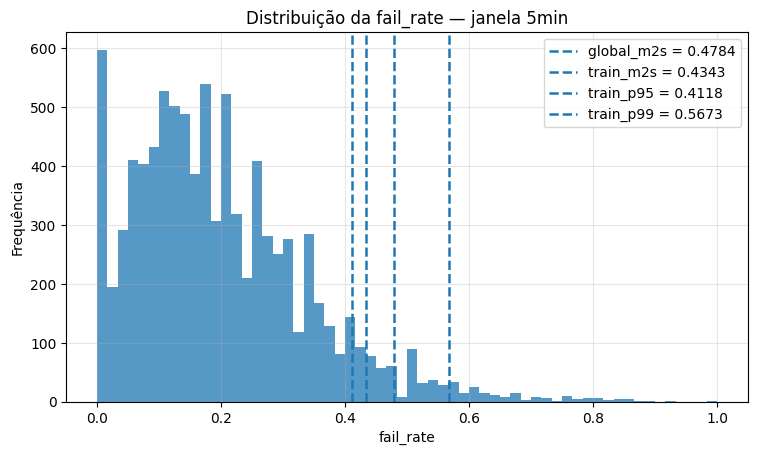

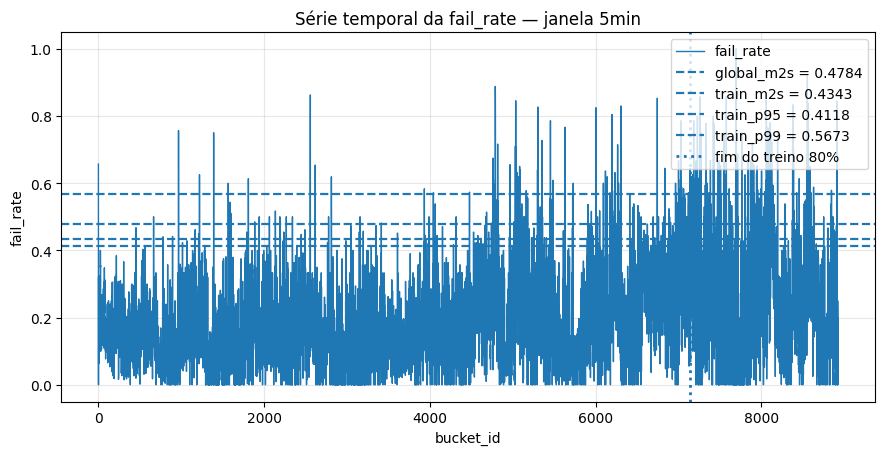

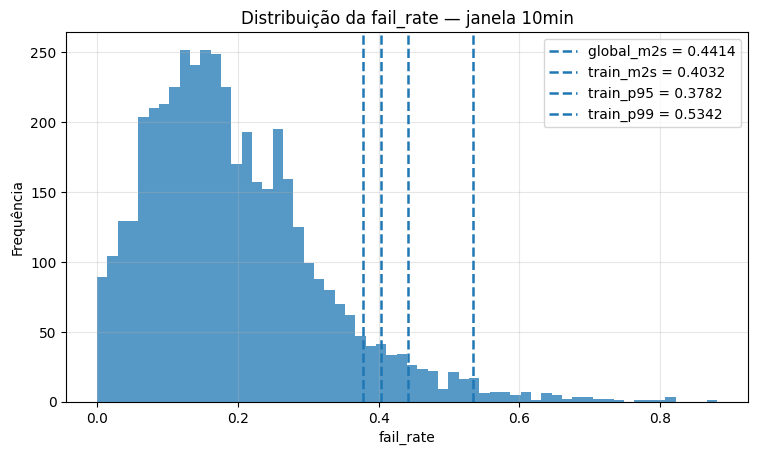

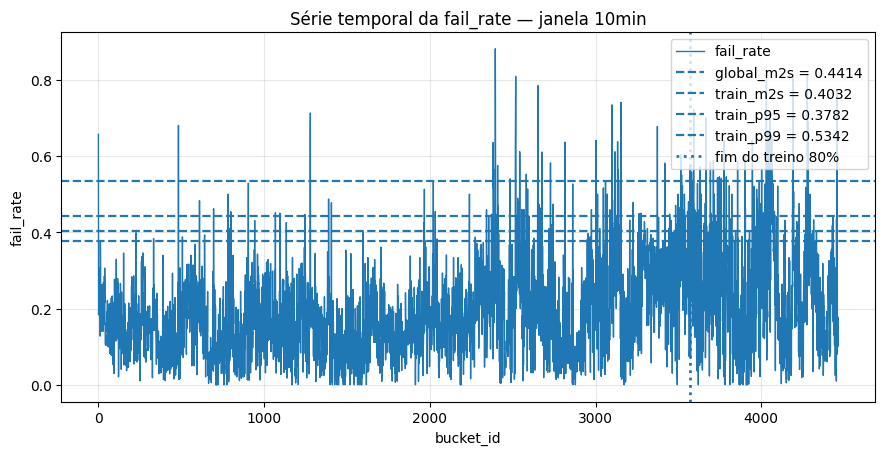


=== Resumo de episódios por cenário ===


,scenario_id,scenario_family,scenario_role,window_minutes,k_before_after,horizon_h,k_minutes,h_minutes,threshold_method,threshold_value,...,one_window_episodes,one_window_episode_rate,train_episodes,test_episodes,cross_split_episodes,normal_windows,before_windows,during_windows,after_windows,during_window_rate
0,W5_K24_H12_P1_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,227,0.796491,147,138,0,4279,2966,390,1295,0.043673
1,W5_K24_H12_P2_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,0,0.000000,24,34,0,7236,960,163,571,0.018253
2,W5_K24_H12_P3_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,0,0.000000,9,17,0,7943,486,99,402,0.011086
3,W5_K24_H12_P1_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,300,0.773196,217,171,0,3187,3767,562,1414,0.062934
4,W5_K24_H12_P2_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,0,0.000000,41,47,0,6543,1345,262,780,0.029339
5,W5_K24_H12_P3_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,0,0.000000,14,21,0,7651,628,156,495,0.017469
6,W5_K24_H12_P1_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,359,0.762208,273,198,0,2653,4213,685,1379,0.076708
7,W5_K24_H12_P2_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,0,0.000000,57,55,0,6172,1631,326,801,0.036506
8,W5_K24_H12_P3_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,0,0.000000,20,24,0,7473,729,190,538,0.021277
9,W5_K24_H12_P1_TRAIN_P99,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p99,0.567328,...,115,0.833333,59,79,0,5783,1961,175,1011,0.019597



=== Impacto na base supervisionada por cenário ===


,scenario_id,scenario_family,scenario_role,window_minutes,k_before_after,horizon_h,k_minutes,h_minutes,threshold_method,threshold_value,...,train_supervised_rows,train_positives,train_positive_rate,test_supervised_rows,test_positives,test_positive_rate,positive_rate_delta_test_minus_train,positives_per_episode,excluded_due_to_during_after,excluded_due_to_incomplete_horizon
0,W5_K24_H12_P1_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,5949,1182,0.198689,1296,805,0.621142,0.422453,6.971930,1685,12
1,W5_K24_H12_P2_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,6792,247,0.036366,1404,302,0.215100,0.178733,9.465517,734,12
2,W5_K24_H12_P3_GLOBAL_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,global_m2s,0.478401,...,6924,108,0.015598,1493,160,0.107167,0.091569,10.307692,501,12
3,W5_K24_H12_P1_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,5637,1673,0.296789,1317,932,0.707669,0.410880,6.713918,1976,12
4,W5_K24_H12_P2_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,6616,409,0.061820,1272,389,0.305818,0.243998,9.068182,1042,12
5,W5_K24_H12_P3_TRAIN_M2S,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_m2s,0.434338,...,6844,168,0.024547,1423,174,0.122277,0.097730,9.771429,651,12
6,W5_K24_H12_P1_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,5566,1983,0.356270,1300,1004,0.772308,0.416037,6.341826,2064,12
7,W5_K24_H12_P2_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,6547,558,0.085230,1256,431,0.343153,0.257923,8.830357,1127,12
8,W5_K24_H12_P3_TRAIN_P95,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p95,0.411765,...,6790,210,0.030928,1400,205,0.146429,0.115501,9.431818,728,12
9,W5_K24_H12_P1_TRAIN_P99,W5_K24_H12,historical_bridge_120_60,5,24,12,120,60,train_p99,0.567328,...,6411,568,0.088598,1333,625,0.468867,0.380269,8.644928,1186,12


[NB10_scenario_diagnostics] Resumo de episódios salvo: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episode_summary.csv
[NB10_scenario_diagnostics] Impacto na rotulagem salvo: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_label_impact.csv
[NB10_scenario_diagnostics] Episódios salvos: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episodes.parquet
[NB10_scenario_diagnostics] Séries rotuladas salvas: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet

=== Decisões metodológicas dos cenários ===


,scenario_id,decision_category,advance_to_nb11,episode_count,supervised_rows,positive_rate,scientific_justification
0,W5_K12_H6_P1_TRAIN_M2S,advance_to_nb11,True,388,7194,0.230748,Promovido para NB11 por usar limiar causal tra...
1,W5_K12_H6_P2_TRAIN_M2S,advance_to_nb11,True,88,8121,0.055166,Promovido para NB11 por usar limiar causal tra...
2,W5_K24_H12_P1_TRAIN_M2S,advance_to_nb11,True,388,6954,0.374605,Promovido para NB11 por usar limiar causal tra...
3,W5_K24_H12_P2_TRAIN_M2S,advance_to_nb11,True,88,7888,0.101166,Promovido para NB11 por usar limiar causal tra...
4,W5_K24_H6_P1_TRAIN_M2S,advance_to_nb11,True,388,6954,0.238712,Promovido para NB11 por usar limiar causal tra...
5,W5_K24_H6_P2_TRAIN_M2S,advance_to_nb11,True,88,7888,0.056795,Promovido para NB11 por usar limiar causal tra...
6,W10_K12_H6_P1_TRAIN_M2S,advance_to_nb11,True,197,3661,0.223983,Promovido para NB11 por usar limiar causal tra...
7,W10_K6_H3_P1_TRAIN_M2S,advance_to_nb11,True,197,3758,0.129590,Promovido para NB11 por usar limiar causal tra...
8,W5_K12_H6_P3_TRAIN_M2S,sensitivity_only,False,35,8482,0.021811,Mantido apenas como sensibilidade restritiva. ...
9,W5_K12_H6_P1_TRAIN_P95,sensitivity_only,False,471,7007,0.279149,Mantido como sensibilidade essencial por usar ...



=== Cenários promovidos para NB11 ===


,scenario_id,window_minutes,k_minutes,h_minutes,threshold_method,persistence_min_windows,episode_count,supervised_rows,positive_rate
0,W5_K12_H6_P1_TRAIN_M2S,5,60,30,train_m2s,1,388,7194,0.230748
1,W5_K12_H6_P2_TRAIN_M2S,5,60,30,train_m2s,2,88,8121,0.055166
2,W5_K24_H12_P1_TRAIN_M2S,5,120,60,train_m2s,1,388,6954,0.374605
3,W5_K24_H12_P2_TRAIN_M2S,5,120,60,train_m2s,2,88,7888,0.101166
4,W5_K24_H6_P1_TRAIN_M2S,5,120,30,train_m2s,1,388,6954,0.238712
5,W5_K24_H6_P2_TRAIN_M2S,5,120,30,train_m2s,2,88,7888,0.056795
6,W10_K12_H6_P1_TRAIN_M2S,10,120,60,train_m2s,1,197,3661,0.223983
7,W10_K6_H3_P1_TRAIN_M2S,10,60,30,train_m2s,1,197,3758,0.129590


[NB10_scenario_diagnostics] Decisões salvas: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_decisions.csv
[NB10_scenario_diagnostics] Cenários promovidos salvos: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_advanced_to_nb11.json


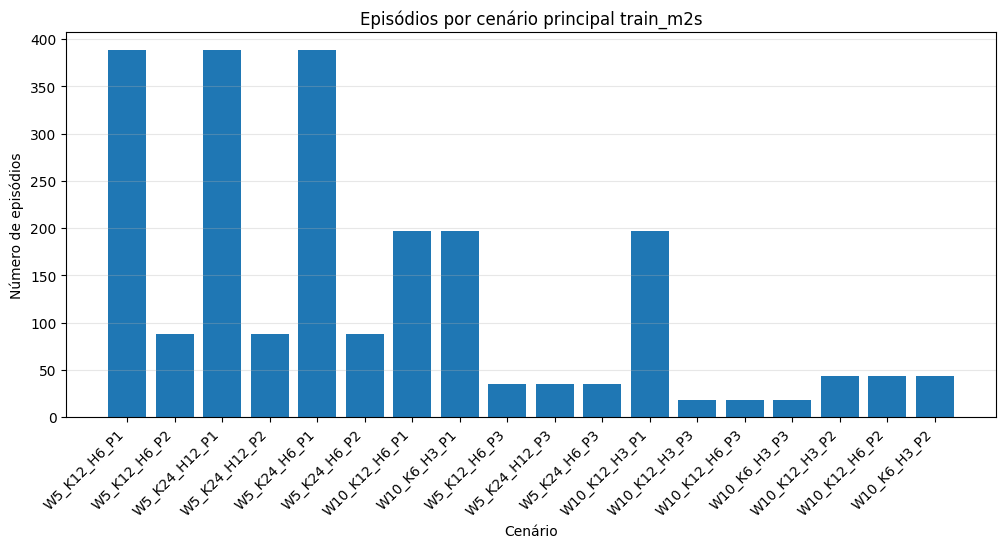

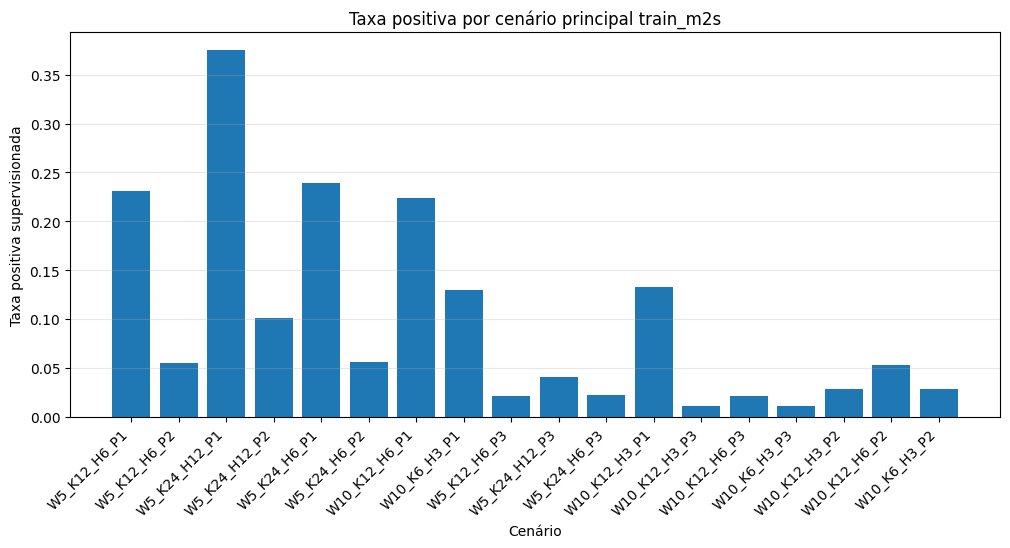

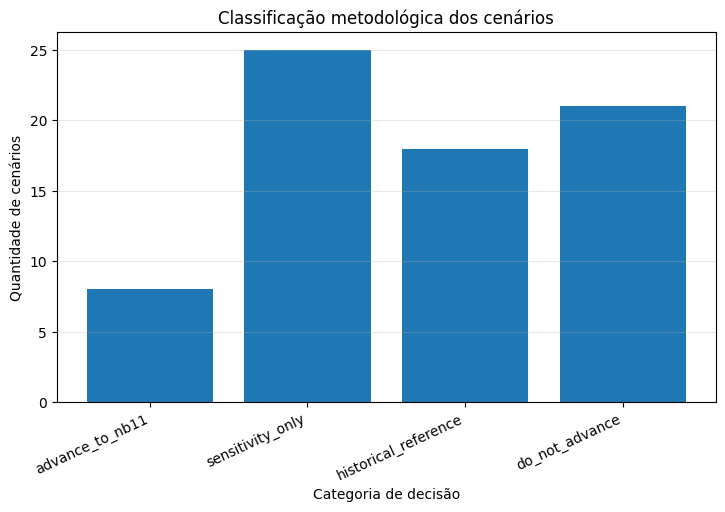

[NB10_scenario_diagnostics] Summary consolidado salvo: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_diagnostics_summary.json

=== Arquivos gerados pelo NB10 ===


,artifact,path,exists
0,10_scenario_fail_rate_descriptive_stats.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
1,10_scenario_thresholds_summary.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
2,10_scenario_episode_summary.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
3,10_scenario_label_impact.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
4,10_scenario_decisions.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
5,10_scenario_episodes.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
6,10_scenario_series_states.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
7,10_scenario_advanced_to_nb11.json,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
8,10_scenario_diagnostics_summary.json,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
9,10_scenario_feature_set_contract.json,/content/drive/MyDrive/Mestrado/04-reports/10_...,True



=== Figuras geradas ===


,figure,repo_path,reports_path
0,w5_hist_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
1,w5_time_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
2,w10_hist_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
3,w10_time_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
4,main_scenarios_episodes,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
5,main_scenarios_positive_rate,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
6,scenario_decision_categories,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...



=== Contagem de decisões ===


,count
decision_category,
sensitivity_only,25
do_not_advance,21
historical_reference,18
advance_to_nb11,8



=== Cenários promovidos para NB11 ===


,scenario_id,window_minutes,k_minutes,h_minutes,threshold_method,persistence_min_windows,episode_count,supervised_rows,positive_rate,scientific_justification
0,W5_K12_H6_P1_TRAIN_M2S,5,60,30,train_m2s,1,388,7194,0.230748,Promovido para NB11 por usar limiar causal tra...
1,W5_K12_H6_P2_TRAIN_M2S,5,60,30,train_m2s,2,88,8121,0.055166,Promovido para NB11 por usar limiar causal tra...
2,W5_K24_H12_P1_TRAIN_M2S,5,120,60,train_m2s,1,388,6954,0.374605,Promovido para NB11 por usar limiar causal tra...
3,W5_K24_H12_P2_TRAIN_M2S,5,120,60,train_m2s,2,88,7888,0.101166,Promovido para NB11 por usar limiar causal tra...
4,W5_K24_H6_P1_TRAIN_M2S,5,120,30,train_m2s,1,388,6954,0.238712,Promovido para NB11 por usar limiar causal tra...
5,W5_K24_H6_P2_TRAIN_M2S,5,120,30,train_m2s,2,88,7888,0.056795,Promovido para NB11 por usar limiar causal tra...
6,W10_K12_H6_P1_TRAIN_M2S,10,120,60,train_m2s,1,197,3661,0.223983,Promovido para NB11 por usar limiar causal tra...
7,W10_K6_H3_P1_TRAIN_M2S,10,60,30,train_m2s,1,197,3758,0.129590,Promovido para NB11 por usar limiar causal tra...



=== Leitura metodológica preliminar ===
O NB10 foi executado como notebook de diagnóstico e seleção metodológica. Os cenários promovidos para NB11 estão registrados em 10_scenario_advanced_to_nb11.json, e as justificativas científicas completas estão em 10_scenario_decisions.csv. A Conclusão da Etapa deve ser elaborada após inspeção do PDF e dos artefatos gerados.


In [ ]:
# ============================================================
# NB10 — Diagnóstico Metodológico de Limiar, Granularidade,
# K/H e Persistência Mínima
# Pipeline PPCOMP_DM
#
# Escopo:
# - Preservar NB00–NB09 como protótipo Kaggle associado ao artigo
# - Carregar a série temporal agregada em janelas de 5 minutos
# - Reconstruir a série temporal agregada em janelas de 10 minutos
# - Definir split temporal antes da estimação dos limiares oficiais
# - Calcular limiar global retrospectivo como referência do protótipo Kaggle
# - Calcular limiares train-only μ+2σ, p95 e p99
# - Aplicar limiares ao trecho futuro sem estatísticas do teste
# - Avaliar combinações de granularidade temporal, K/H e persistência mínima
# - Detectar episódios críticos por cenário
# - Reconstruir estados NORMAL/BEFORE/DURING/AFTER
# - Construir alvo supervisionado y_t para impacto nos rótulos
# - Classificar cenários em avanço, sensibilidade, referência ou descarte
# - Salvar CSV, Parquet, figuras e summary JSON para rastreabilidade
#
# Importante:
# - O limiar global é referência retrospectiva do protótipo Kaggle
# - Os cenários train-only não usam dados do teste na estimação do limiar
# - A persistência mínima é avaliada, não decidida previamente
# - O p99 é diagnóstico de severidade extrema, não cenário principal
# - O Python gera insumos e decisões estruturadas
# - A Conclusão da Etapa deve ser escrita após análise dos artefatos gerados
# ============================================================

from pathlib import Path
import os
import sys
import subprocess
import importlib
import random
import json
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# ─────────────────────────────────────────────────────────────
# BLOCO 0 — Bootstrap
# ─────────────────────────────────────────────────────────────

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
else:
    print("[Bootstrap] Google Drive já montado.")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    print(f"[Bootstrap] Clonando repositório em: {REPO_DIR}")
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)

os.chdir(str(REPO_DIR))
print("[Bootstrap] CWD =", os.getcwd())

repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

importlib.invalidate_caches()

try:
    from src.paths import FEATURES_PATH, REPORTS_PATH, ensure_dirs
    ensure_dirs()
except Exception as e:
    print("[Bootstrap] Aviso: não foi possível importar src.paths.")
    print("[Bootstrap] Tentando usar caminhos padrão no Google Drive.")
    print("[Bootstrap] Detalhe:", e)

    FEATURES_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/03-features")
    REPORTS_PATH = Path("/content/drive/MyDrive/Mestrado/04-reports")
    FEATURES_PATH.mkdir(parents=True, exist_ok=True)
    REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("FEATURES_PATH =", FEATURES_PATH)
print("REPORTS_PATH =", REPORTS_PATH)


def log(msg: str) -> None:
    """Imprime mensagens padronizadas desta etapa do pipeline."""
    print(f"[NB10_scenario_diagnostics] {msg}")


# ─────────────────────────────────────────────────────────────
# BLOCO 1 — Parâmetros do notebook
# ─────────────────────────────────────────────────────────────

TRAIN_FRACTION = 0.80
STD_DDOF = 0
BASE_WINDOW_MINUTES = 5

PERSISTENCE_VALUES = [1, 2, 3]
THRESHOLD_METHODS = ["global_m2s", "train_m2s", "train_p95", "train_p99"]


# Contrato normativo de atributos para os consumidores downstream.
# event_FAIL_count permanece nos dados apenas para proveniência e auditoria.
RAW_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

TEMPORAL_CORE = RAW_CORE + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

PROVENANCE_ONLY_COLUMNS = ["event_FAIL_count"]
FORBIDDEN_PREDICTOR_PATTERNS = [
    "target",
    "label",
    "state",
    "during",
    "before",
    "after",
    "critical",
    "episode",
    "future",
    "horizon",
    "bucket_start_us",
    "bucket_id",
    "time",
    "timestamp",
    "event_FAIL_count",
]

# Cenários K/H em unidades de janela da respectiva granularidade.
# A interpretação em minutos é calculada automaticamente.
TEMPORAL_SCENARIOS = [
    {
        "scenario_family": "W5_K24_H12",
        "window_minutes": 5,
        "k_before_after": 24,
        "horizon_h": 12,
        "role": "historical_bridge_120_60",
        "description": "Janela 5min, BEFORE/AFTER 120min, horizonte 60min; ponte direta com o protótipo Kaggle.",
    },
    {
        "scenario_family": "W5_K12_H6",
        "window_minutes": 5,
        "k_before_after": 12,
        "horizon_h": 6,
        "role": "shorter_operational_60_30",
        "description": "Janela 5min, BEFORE/AFTER 60min, horizonte 30min; reação operacional mais curta.",
    },
    {
        "scenario_family": "W5_K24_H6",
        "window_minutes": 5,
        "k_before_after": 24,
        "horizon_h": 6,
        "role": "isolate_horizon_effect_120_30",
        "description": "Janela 5min, BEFORE/AFTER 120min, horizonte 30min; isola redução de H.",
    },
    {
        "scenario_family": "W10_K12_H6",
        "window_minutes": 10,
        "k_before_after": 12,
        "horizon_h": 6,
        "role": "smoothed_120_60",
        "description": "Janela 10min, BEFORE/AFTER 120min, horizonte 60min; versão suavizada do cenário retrospectivo.",
    },
    {
        "scenario_family": "W10_K6_H3",
        "window_minutes": 10,
        "k_before_after": 6,
        "horizon_h": 3,
        "role": "smoothed_shorter_60_30",
        "description": "Janela 10min, BEFORE/AFTER 60min, horizonte 30min; suavização com horizonte curto.",
    },
    {
        "scenario_family": "W10_K12_H3",
        "window_minutes": 10,
        "k_before_after": 12,
        "horizon_h": 3,
        "role": "smoothed_isolate_horizon_120_30",
        "description": "Janela 10min, BEFORE/AFTER 120min, horizonte 30min; isola redução de H em série suavizada.",
    },
]

# Critérios práticos de decisão metodológica.
# Esses limites não substituem avaliação científica posterior; servem para triagem rastreável.
MIN_EPISODES_ADVANCE = 50
MIN_POSITIVE_RATE_ADVANCE = 0.03
MAX_POSITIVE_RATE_ADVANCE = 0.50
MIN_SUPERVISED_ROWS_ADVANCE = 500

FIG_DIR = REPO_DIR / "figures_nb10_scenarios"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_FIG_DIR = REPORTS_PATH / "figures_nb10_scenarios"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PREFIX = "10_scenario"

FAIL_RATE_STATS_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_fail_rate_descriptive_stats.csv"
THRESHOLDS_SUMMARY_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_thresholds_summary.csv"
EPISODE_SUMMARY_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_episode_summary.csv"
LABEL_IMPACT_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_label_impact.csv"
SCENARIO_DECISIONS_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_decisions.csv"

EPISODES_ALL_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_episodes.parquet"
SCENARIO_SERIES_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_series_states.parquet"
ADVANCED_SCENARIOS_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_advanced_to_nb11.json"
SUMMARY_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_diagnostics_summary.json"
FEATURE_SET_CONTRACT_FILE = REPORTS_PATH / f"{OUTPUT_PREFIX}_feature_set_contract.json"

# Candidatos de entrada. O primeiro existente com bucket_id e fail_rate será usado.
# Se fail_rate estiver ausente, mas n_events e n_failed estiverem presentes, ela será recalculada.
INPUT_CANDIDATES = [
    FEATURES_PATH / "window_5min_series.parquet",
    FEATURES_PATH / "window_5min_series_scored.parquet",
    FEATURES_PATH / "window_5min_features.parquet",
    FEATURES_PATH / "window_5min_labeled.parquet",
]

log("Parâmetros principais definidos.")
print("TRAIN_FRACTION =", TRAIN_FRACTION)
print("STD_DDOF =", STD_DDOF)
print("PERSISTENCE_VALUES =", PERSISTENCE_VALUES)
print("THRESHOLD_METHODS =", THRESHOLD_METHODS)
print("TEMPORAL_SCENARIOS =", len(TEMPORAL_SCENARIOS))
print("RAW_CORE =", RAW_CORE)
print("TEMPORAL_CORE =", TEMPORAL_CORE)


# ─────────────────────────────────────────────────────────────
# BLOCO 2 — Funções auxiliares
# ─────────────────────────────────────────────────────────────



def validate_feature_contract() -> None:
    """Valida nomes, cardinalidades e exclusões do contrato ativo."""
    assert "event_FAIL_count" not in RAW_CORE
    assert "event_FAIL_count" not in TEMPORAL_CORE
    assert len(RAW_CORE) == 6
    assert len(TEMPORAL_CORE) == 13
    assert len(RAW_CORE) == len(set(RAW_CORE))
    assert len(TEMPORAL_CORE) == len(set(TEMPORAL_CORE))

    forbidden_hits = [
        feature
        for feature in TEMPORAL_CORE
        if any(pattern.lower() in feature.lower() for pattern in FORBIDDEN_PREDICTOR_PATTERNS)
    ]
    if forbidden_hits:
        raise AssertionError(
            "Atributos proibidos no contrato ativo: " + ", ".join(sorted(forbidden_hits))
        )


def validate_failure_count_provenance(df: pd.DataFrame, context: str) -> None:
    """Exige igualdade exata entre a coluna mantida e a coluna de proveniência."""
    required = {"n_failed", "event_FAIL_count"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(
            f"[{context}] Colunas obrigatórias ausentes para auditoria de redundância: {missing}"
        )

    left = pd.to_numeric(df["n_failed"], errors="coerce")
    right = pd.to_numeric(df["event_FAIL_count"], errors="coerce")
    unequal = ~(left.eq(right) | (left.isna() & right.isna()))

    if bool(unequal.any()):
        sample = df.loc[unequal, ["n_failed", "event_FAIL_count"]].head(10)
        raise AssertionError(
            f"[{context}] n_failed diverge de event_FAIL_count em "
            f"{int(unequal.sum())} linhas. Amostra:\n{sample}"
        )


def validate_fail_rate_semantics(df: pd.DataFrame, context: str, atol: float = 1e-12) -> None:
    """Confere fail_rate = n_failed / n_events, com zero em janelas vazias."""
    required = {"fail_rate", "n_events", "n_failed"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(f"[{context}] Colunas ausentes para validar fail_rate: {missing}")

    n_events = pd.to_numeric(df["n_events"], errors="coerce").fillna(0)
    n_failed = pd.to_numeric(df["n_failed"], errors="coerce").fillna(0)
    observed = pd.to_numeric(df["fail_rate"], errors="coerce")

    expected = np.where(n_events > 0, n_failed / n_events, 0.0)
    diff = np.abs(observed.to_numpy(dtype=float) - expected.astype(float))

    if np.isnan(diff).any() or float(np.nanmax(diff, initial=0.0)) > atol:
        raise AssertionError(
            f"[{context}] fail_rate incompatível com n_failed/n_events; "
            f"diferença máxima={float(np.nanmax(diff)):.6g}"
        )


def exact_duplicate_pairs(df: pd.DataFrame, features: list[str]) -> list[tuple[str, str]]:
    """Retorna pares de colunas ativas com igualdade exata de valores."""
    available = [feature for feature in features if feature in df.columns]
    duplicates = []

    for i, left_name in enumerate(available):
        left = df[left_name]
        for right_name in available[i + 1:]:
            right = df[right_name]
            if left.equals(right):
                duplicates.append((left_name, right_name))

    return duplicates


def validate_no_unjustified_exact_duplicates(
    df: pd.DataFrame,
    features: list[str],
    context: str,
) -> None:
    """Interrompe a execução quando o vetor ativo contém duplicidade exata."""
    duplicates = exact_duplicate_pairs(df, features)
    if duplicates:
        raise AssertionError(
            f"[{context}] Duplicidades exatas não justificadas nos preditores: {duplicates}"
        )


def find_input_series(candidates):
    """
    Seleciona o primeiro arquivo Parquet existente que contenha
    as colunas mínimas para o NB10.

    Se o arquivo não possuir fail_rate, mas possuir n_events e n_failed,
    a fail_rate é recalculada pela definição oficial:
        fail_rate = n_failed / n_events, com fail_rate = 0 quando n_events = 0.
    """
    checked = []

    for path in candidates:
        checked.append(str(path))

        if not path.exists():
            continue

        df = pd.read_parquet(path)

        if "bucket_id" not in df.columns:
            log(f"Arquivo encontrado, mas sem bucket_id: {path}")
            continue

        if "fail_rate" not in df.columns:
            if {"n_events", "n_failed"}.issubset(df.columns):
                log(f"Arquivo sem fail_rate, mas com n_events/n_failed. Recalculando fail_rate: {path}")
                df = df.copy()
                df["fail_rate"] = np.where(
                    df["n_events"].fillna(0).astype(float) > 0,
                    df["n_failed"].fillna(0).astype(float) / df["n_events"].fillna(0).astype(float),
                    0.0,
                )
            else:
                log(f"Arquivo encontrado, mas sem fail_rate e sem n_events/n_failed: {path}")
                continue

        return path, df

    raise FileNotFoundError(
        "Nenhum arquivo de entrada adequado foi encontrado. "
        "Arquivos verificados:\n" + "\n".join(checked)
    )


def as_float(x):
    """Converte valores NumPy/Pandas para float nativo com tratamento de NaN."""
    if pd.isna(x):
        return None
    return float(x)


def as_int(x):
    """Converte valores NumPy/Pandas para int nativo com tratamento de NaN."""
    if pd.isna(x):
        return None
    return int(x)


def save_current_figure(filename: str) -> dict:
    """Salva a figura atual no repositório e em REPORTS_PATH."""
    out_repo = FIG_DIR / filename
    out_reports = REPORT_FIG_DIR / filename

    plt.savefig(out_repo, dpi=300, bbox_inches="tight")
    plt.savefig(out_reports, dpi=300, bbox_inches="tight")

    return {
        "repo_path": str(out_repo),
        "reports_path": str(out_reports),
    }


def format_float(x, digits=6):
    """Formata valores numéricos para tabelas/legendas."""
    if x is None or pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"


def prepare_5min_series(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Prepara a série de 5 minutos.

    Mantém uma linha por bucket_id, recalcula fail_rate de forma canônica
    e preserva contadores necessários para reconstrução posterior da série de 10 minutos.
    """
    df = df_raw.copy()

    df = (
        df
        .sort_values("bucket_id")
        .drop_duplicates(subset=["bucket_id"], keep="first")
        .reset_index(drop=True)
    )

    df["bucket_id"] = df["bucket_id"].astype(int)

    if "n_events" not in df.columns:
        df["n_events"] = np.nan

    if "n_failed" not in df.columns:
        df["n_failed"] = np.nan

    df["n_events"] = df["n_events"].fillna(0).astype(float)
    df["n_failed"] = df["n_failed"].fillna(0).astype(float)

    df["fail_rate"] = np.where(
        df["n_events"] > 0,
        df["n_failed"] / df["n_events"],
        0.0,
    )

    if "bucket_start_us" not in df.columns:
        df["bucket_start_us"] = df["bucket_id"] * BASE_WINDOW_MINUTES * 60 * 1_000_000

    df["window_minutes"] = 5
    df["row_position"] = np.arange(len(df), dtype=int)

    return df

def prepare_10min_series(df_5: pd.DataFrame) -> pd.DataFrame:
    """
    Reconstrói a série de 10 minutos a partir da série de 5 minutos.

    Importante: a fail_rate de 10 minutos não é calculada como média simples
    das taxas de 5 minutos. Ela é recalculada por soma dos numeradores e denominadores:
        fail_rate_10min = sum(n_failed) / sum(n_events)
    Isso preserva a interpretação estatística da taxa de falha.

    Observação técnica:
    - A coluna bucket_10_id é usada como identificador da nova janela.
    - A coluna bucket_id original de 5 minutos NÃO é agregada como bucket_id,
      para evitar duplicidade de nomes após o rename.
    - Para rastreabilidade, preservamos first_bucket_5min e last_bucket_5min.
    """
    df = df_5.copy()
    df["bucket_10_id"] = (df["bucket_id"] // 2).astype(int)

    sum_cols = [
        "n_events",
        "n_failed",
        "n_machines",
        "n_collections",
        "event_FAIL_count",
        "event_SCHEDULE_count",
        "event_FINISH_count",
        "event_ENABLE_count",
        "event_LOST_count",
        "event_EVICT_count",
        "event_KILL_count",
    ]

    available_sum_cols = [c for c in sum_cols if c in df.columns]

    agg_dict = {
        "bucket_start_us": "min",
        "bucket_id": ["min", "max"],
    }

    for col in available_sum_cols:
        agg_dict[col] = "sum"

    df_10 = (
        df
        .groupby("bucket_10_id", as_index=False)
        .agg(agg_dict)
    )

    # Achata MultiIndex gerado por agregações múltiplas.
    flat_cols = []
    for col in df_10.columns:
        if isinstance(col, tuple):
            base, stat = col
            if base == "bucket_10_id":
                flat_cols.append("bucket_10_id")
            elif base == "bucket_id" and stat == "min":
                flat_cols.append("first_bucket_5min")
            elif base == "bucket_id" and stat == "max":
                flat_cols.append("last_bucket_5min")
            elif stat in ("", None):
                flat_cols.append(str(base))
            else:
                flat_cols.append(str(base))
        else:
            flat_cols.append(str(col))

    df_10.columns = flat_cols

    df_10 = (
        df_10
        .rename(columns={"bucket_10_id": "bucket_id"})
        .sort_values("bucket_id")
        .reset_index(drop=True)
    )

    if "n_events" not in df_10.columns:
        raise ValueError("n_events é necessário para reconstruir janela de 10 minutos.")

    if "n_failed" not in df_10.columns:
        raise ValueError("n_failed é necessário para reconstruir janela de 10 minutos.")

    df_10["fail_rate"] = np.where(
        df_10["n_events"].fillna(0).astype(float) > 0,
        df_10["n_failed"].fillna(0).astype(float) / df_10["n_events"].fillna(0).astype(float),
        0.0,
    )

    df_10["window_minutes"] = 10
    df_10["row_position"] = np.arange(len(df_10), dtype=int)

    return df_10

def add_temporal_split(df: pd.DataFrame) -> pd.DataFrame:
    """
    Define split temporal treino/teste antes de qualquer estimação causal.

    Esse passo é essencial para evitar vazamento temporal nos limiares train-only.
    """
    out = df.copy()
    n_rows = len(out)
    train_rows = int(np.floor(n_rows * TRAIN_FRACTION))

    if train_rows <= 0 or train_rows >= n_rows:
        raise ValueError(f"Split temporal inválido para série com {n_rows} linhas.")

    out["row_position"] = np.arange(n_rows, dtype=int)
    out["temporal_partition"] = np.where(out["row_position"] < train_rows, "train", "test")

    return out


def descriptive_stats(values: pd.Series, scope: str, window_minutes: int) -> dict:
    """Calcula estatísticas descritivas da fail_rate por escopo e granularidade."""
    values = values.dropna().astype(float)

    return {
        "window_minutes": int(window_minutes),
        "scope": scope,
        "count": int(values.shape[0]),
        "zero_count": int((values == 0).sum()),
        "zero_rate": float((values == 0).mean()) if len(values) else np.nan,
        "nonzero_count": int((values > 0).sum()),
        "mean": float(values.mean()) if len(values) else np.nan,
        "std": float(values.std(ddof=STD_DDOF)) if len(values) else np.nan,
        "min": float(values.min()) if len(values) else np.nan,
        "p01": float(values.quantile(0.01)) if len(values) else np.nan,
        "p05": float(values.quantile(0.05)) if len(values) else np.nan,
        "p25": float(values.quantile(0.25)) if len(values) else np.nan,
        "median": float(values.quantile(0.50)) if len(values) else np.nan,
        "p75": float(values.quantile(0.75)) if len(values) else np.nan,
        "p90": float(values.quantile(0.90)) if len(values) else np.nan,
        "p95": float(values.quantile(0.95)) if len(values) else np.nan,
        "p99": float(values.quantile(0.99)) if len(values) else np.nan,
        "max": float(values.max()) if len(values) else np.nan,
    }


def compute_thresholds(df: pd.DataFrame, window_minutes: int) -> pd.DataFrame:
    """
    Calcula limiares para uma granularidade específica.

    global_m2s usa toda a série e é mantido apenas como referência histórica.
    train_m2s, train_p95 e train_p99 usam apenas o trecho de treino.
    """
    full_fail = df["fail_rate"].astype(float)
    train_fail = df.loc[df["temporal_partition"] == "train", "fail_rate"].astype(float)

    global_mu = float(full_fail.mean())
    global_std = float(full_fail.std(ddof=STD_DDOF))
    global_p95 = float(full_fail.quantile(0.95))
    global_p99 = float(full_fail.quantile(0.99))

    train_mu = float(train_fail.mean())
    train_std = float(train_fail.std(ddof=STD_DDOF))
    train_p95 = float(train_fail.quantile(0.95))
    train_p99 = float(train_fail.quantile(0.99))

    rows = [
        {
            "window_minutes": int(window_minutes),
            "threshold_method": "global_m2s",
            "description": "Limiar global retrospectivo μ + 2σ calculado sobre toda a série",
            "fit_scope": "full_series",
            "uses_test_statistics": True,
            "mu": global_mu,
            "std": global_std,
            "p95": global_p95,
            "p99": global_p99,
            "threshold_value": float(global_mu + 2 * global_std),
            "role": "historical_reference",
        },
        {
            "window_minutes": int(window_minutes),
            "threshold_method": "train_m2s",
            "description": "Limiar causal μ + 2σ calculado apenas no treino",
            "fit_scope": "train_only",
            "uses_test_statistics": False,
            "mu": train_mu,
            "std": train_std,
            "p95": train_p95,
            "p99": train_p99,
            "threshold_value": float(train_mu + 2 * train_std),
            "role": "main_candidate",
        },
        {
            "window_minutes": int(window_minutes),
            "threshold_method": "train_p95",
            "description": "Limiar causal p95 calculado apenas no treino",
            "fit_scope": "train_only",
            "uses_test_statistics": False,
            "mu": train_mu,
            "std": train_std,
            "p95": train_p95,
            "p99": train_p99,
            "threshold_value": train_p95,
            "role": "essential_sensitivity",
        },
        {
            "window_minutes": int(window_minutes),
            "threshold_method": "train_p99",
            "description": "Limiar causal p99 calculado apenas no treino",
            "fit_scope": "train_only",
            "uses_test_statistics": False,
            "mu": train_mu,
            "std": train_std,
            "p95": train_p95,
            "p99": train_p99,
            "threshold_value": train_p99,
            "role": "extreme_severity_diagnostic",
        },
    ]

    return pd.DataFrame(rows)


def detect_episodes_from_flag(
    df: pd.DataFrame,
    flag_col: str,
    scenario_id: str,
    scenario_family: str,
    threshold_method: str,
    threshold_value: float,
    persistence_min_windows: int,
    window_minutes: int,
    split_train_last_position: int,
) -> pd.DataFrame:
    """
    Detecta episódios como sequências máximas de janelas críticas contíguas.

    A persistência mínima é aplicada sobre a sequência original de janelas
    acima do limiar. Sequências com duração menor que persistence_min_windows
    são descartadas. Sequências válidas mantêm todas as janelas do trecho como DURING.
    """
    flags = df[flag_col].fillna(False).astype(bool).to_numpy()
    bucket_ids = df["bucket_id"].to_numpy()

    rows = []
    in_run = False
    start_idx = None

    def close_run(end_idx):
        duration = end_idx - start_idx + 1

        if duration < persistence_min_windows:
            return

        start_bucket = int(bucket_ids[start_idx])
        end_bucket = int(bucket_ids[end_idx])

        if end_idx <= split_train_last_position:
            partition = "train"
        elif start_idx > split_train_last_position:
            partition = "test"
        else:
            partition = "cross_split"

        rows.append({
            "scenario_id": scenario_id,
            "scenario_family": scenario_family,
            "threshold_method": threshold_method,
            "threshold_value": float(threshold_value),
            "persistence_min_windows": int(persistence_min_windows),
            "window_minutes": int(window_minutes),
            "episode_id": len(rows) + 1,
            "start_index": int(start_idx),
            "end_index": int(end_idx),
            "start_bucket": start_bucket,
            "end_bucket": end_bucket,
            "duration_windows": int(duration),
            "duration_minutes": int(duration * window_minutes),
            "episode_partition": partition,
        })

    for i, is_crit in enumerate(flags):
        if is_crit and not in_run:
            in_run = True
            start_idx = i
        elif not is_crit and in_run:
            close_run(i - 1)
            in_run = False
            start_idx = None

    if in_run:
        close_run(len(flags) - 1)

    return pd.DataFrame(rows)


def build_valid_critical_flag(n_rows: int, episodes_df: pd.DataFrame) -> np.ndarray:
    """Reconstrói o vetor booleano de janelas críticas válidas a partir dos episódios."""
    flag = np.zeros(n_rows, dtype=bool)

    if episodes_df.empty:
        return flag

    for _, ep in episodes_df.iterrows():
        s = int(ep["start_index"])
        e = int(ep["end_index"])
        flag[s:e + 1] = True

    return flag


def assign_states_from_episodes(
    base_df: pd.DataFrame,
    episodes_df: pd.DataFrame,
    k_before_after: int,
) -> pd.DataFrame:
    """
    Atribui estados NORMAL/BEFORE/DURING/AFTER a partir dos episódios.

    Precedência:
    DURING > BEFORE > AFTER > NORMAL
    """
    n = len(base_df)

    during = np.zeros(n, dtype=bool)
    before = np.zeros(n, dtype=bool)
    after = np.zeros(n, dtype=bool)

    if not episodes_df.empty:
        for _, ep in episodes_df.iterrows():
            s = int(ep["start_index"])
            e = int(ep["end_index"])

            during[s:e + 1] = True

            b0 = max(0, s - k_before_after)
            b1 = max(0, s - 1)
            if b0 <= b1:
                before[b0:b1 + 1] = True

            a0 = min(n - 1, e + 1)
            a1 = min(n - 1, e + k_before_after)
            if a0 <= a1:
                after[a0:a1 + 1] = True

    state = np.full(n, "NORMAL", dtype=object)
    state[after] = "AFTER"
    state[before] = "BEFORE"
    state[during] = "DURING"

    out = base_df.copy()
    out["state"] = state
    out["is_during"] = during
    out["is_before"] = state == "BEFORE"
    out["is_after"] = state == "AFTER"
    out["is_normal"] = state == "NORMAL"

    return out


def build_supervised_target(
    state_df: pd.DataFrame,
    horizon_h: int,
) -> pd.DataFrame:
    """
    Constrói y_t = 1 se existe DURING em (t, t+H].

    A base supervisionada é elegível apenas para estados NORMAL/BEFORE
    e para janelas com horizonte futuro completo.
    """
    out = state_df.copy()
    n = len(out)

    during = out["is_during"].astype(bool).to_numpy()
    y = np.zeros(n, dtype=int)
    horizon_complete = np.zeros(n, dtype=bool)

    for i in range(n):
        if i + horizon_h < n:
            horizon_complete[i] = True
            y[i] = int(during[i + 1:i + horizon_h + 1].any())

    eligible_state = out["state"].isin(["NORMAL", "BEFORE"]).to_numpy()
    eligible_supervised = eligible_state & horizon_complete

    out["horizon_complete"] = horizon_complete
    out["eligible_supervised"] = eligible_supervised
    out["y"] = y

    return out


def summarize_episode_scenario(
    scenario_meta: dict,
    scenario_df: pd.DataFrame,
    episodes_df: pd.DataFrame,
) -> dict:
    """Gera resumo de episódios e distribuição de estados por cenário."""
    n = len(scenario_df)
    critical_windows = int(scenario_df["is_critical"].sum())

    if episodes_df.empty:
        episode_count = 0
        duration_mean = np.nan
        duration_median = np.nan
        duration_min = np.nan
        duration_max = np.nan
        one_window_episodes = 0
        train_episodes = 0
        test_episodes = 0
        cross_split_episodes = 0
    else:
        episode_count = int(len(episodes_df))
        duration_mean = float(episodes_df["duration_windows"].mean())
        duration_median = float(episodes_df["duration_windows"].median())
        duration_min = int(episodes_df["duration_windows"].min())
        duration_max = int(episodes_df["duration_windows"].max())
        one_window_episodes = int((episodes_df["duration_windows"] == 1).sum())
        train_episodes = int((episodes_df["episode_partition"] == "train").sum())
        test_episodes = int((episodes_df["episode_partition"] == "test").sum())
        cross_split_episodes = int((episodes_df["episode_partition"] == "cross_split").sum())

    state_counts = (
        scenario_df["state"]
        .value_counts()
        .reindex(["NORMAL", "BEFORE", "DURING", "AFTER"], fill_value=0)
    )

    return {
        **scenario_meta,
        "total_windows": int(n),
        "critical_windows": critical_windows,
        "critical_window_rate": float(critical_windows / n) if n else np.nan,
        "episode_count": episode_count,
        "episode_density_per_1000_windows": float(episode_count / n * 1000) if n else np.nan,
        "episode_duration_mean_windows": duration_mean,
        "episode_duration_median_windows": duration_median,
        "episode_duration_min_windows": duration_min,
        "episode_duration_max_windows": duration_max,
        "episode_duration_max_minutes": (
            duration_max * scenario_meta["window_minutes"]
            if not pd.isna(duration_max)
            else np.nan
        ),
        "one_window_episodes": one_window_episodes,
        "one_window_episode_rate": (
            float(one_window_episodes / episode_count)
            if episode_count else np.nan
        ),
        "train_episodes": train_episodes,
        "test_episodes": test_episodes,
        "cross_split_episodes": cross_split_episodes,
        "normal_windows": int(state_counts["NORMAL"]),
        "before_windows": int(state_counts["BEFORE"]),
        "during_windows": int(state_counts["DURING"]),
        "after_windows": int(state_counts["AFTER"]),
        "during_window_rate": float(state_counts["DURING"] / n) if n else np.nan,
    }


def summarize_label_impact(
    scenario_meta: dict,
    scenario_df: pd.DataFrame,
) -> dict:
    """Resume o impacto do cenário na base supervisionada de antecipação."""
    eligible = scenario_df[scenario_df["eligible_supervised"]].copy()

    total_windows = len(scenario_df)
    supervised_rows = len(eligible)
    positives = int(eligible["y"].sum()) if supervised_rows else 0
    negatives = int(supervised_rows - positives)

    before_rows = eligible[eligible["state"] == "BEFORE"].copy()
    normal_rows = eligible[eligible["state"] == "NORMAL"].copy()

    before_y1 = int(before_rows["y"].sum()) if len(before_rows) else 0
    before_y0 = int(len(before_rows) - before_y1)
    normal_y1 = int(normal_rows["y"].sum()) if len(normal_rows) else 0
    normal_y0 = int(len(normal_rows) - normal_y1)

    train_eligible = eligible[eligible["temporal_partition"] == "train"]
    test_eligible = eligible[eligible["temporal_partition"] == "test"]

    train_pos = int(train_eligible["y"].sum()) if len(train_eligible) else 0
    test_pos = int(test_eligible["y"].sum()) if len(test_eligible) else 0

    train_positive_rate = float(train_pos / len(train_eligible)) if len(train_eligible) else np.nan
    test_positive_rate = float(test_pos / len(test_eligible)) if len(test_eligible) else np.nan

    pos_per_episode = (
        float(positives / scenario_meta["episode_count"])
        if scenario_meta.get("episode_count", 0)
        else np.nan
    )

    return {
        **scenario_meta,
        "total_windows": int(total_windows),
        "supervised_rows": int(supervised_rows),
        "positives": int(positives),
        "negatives": int(negatives),
        "positive_rate": float(positives / supervised_rows) if supervised_rows else np.nan,
        "class_balance_neg_pos_ratio": float(negatives / positives) if positives else np.nan,
        "eligible_before_rows": int(len(before_rows)),
        "eligible_before_y1": int(before_y1),
        "eligible_before_y0": int(before_y0),
        "eligible_normal_rows": int(len(normal_rows)),
        "eligible_normal_y1": int(normal_y1),
        "eligible_normal_y0": int(normal_y0),
        "train_supervised_rows": int(len(train_eligible)),
        "train_positives": int(train_pos),
        "train_positive_rate": train_positive_rate,
        "test_supervised_rows": int(len(test_eligible)),
        "test_positives": int(test_pos),
        "test_positive_rate": test_positive_rate,
        "positive_rate_delta_test_minus_train": (
            float(test_positive_rate - train_positive_rate)
            if not pd.isna(test_positive_rate) and not pd.isna(train_positive_rate)
            else np.nan
        ),
        "positives_per_episode": pos_per_episode,
        "excluded_due_to_during_after": int(
            scenario_df["state"].isin(["DURING", "AFTER"]).sum()
        ),
        "excluded_due_to_incomplete_horizon": int(
            (~scenario_df["horizon_complete"]).sum()
        ),
    }


def decide_scenario(row: pd.Series) -> dict:
    """
    Classifica cada cenário para orientar os próximos notebooks.

    A decisão é uma triagem científica documentada, não uma verdade absoluta.
    A interpretação final deve considerar as tabelas, figuras e objetivos da dissertação.
    """
    threshold_method = row["threshold_method"]
    persistence = int(row["persistence_min_windows"])
    episode_count = int(row["episode_count"])
    positive_rate = row["positive_rate"]
    supervised_rows = int(row["supervised_rows"])
    scenario_family = row["scenario_family"]

    reasons = []

    if threshold_method == "global_m2s":
        return {
            "decision_category": "historical_reference",
            "advance_to_nb11": False,
            "scientific_justification": (
                "Mantido como referência histórica do artigo. Não avança como cenário causal "
                "porque usa estatísticas da série completa, incluindo o trecho de teste."
            ),
        }

    if threshold_method == "train_p99":
        return {
            "decision_category": "do_not_advance",
            "advance_to_nb11": False,
            "scientific_justification": (
                "Não avança porque p99 caracteriza severidade extrema e tende a transformar "
                "a tarefa de antecipação em um problema de eventos raros, com redução excessiva "
                "da base positiva."
            ),
        }

    if persistence == 3:
        return {
            "decision_category": "sensitivity_only",
            "advance_to_nb11": False,
            "scientific_justification": (
                "Mantido apenas como sensibilidade restritiva. Persistência mínima de 3 janelas "
                "exige criticidade mais prolongada e tende a reduzir episódios e positivos, "
                "podendo alterar substancialmente a tarefa supervisionada."
            ),
        }

    if episode_count < MIN_EPISODES_ADVANCE:
        reasons.append(
            f"episódios insuficientes para avanço principal ({episode_count} < {MIN_EPISODES_ADVANCE})"
        )

    if supervised_rows < MIN_SUPERVISED_ROWS_ADVANCE:
        reasons.append(
            f"linhas supervisionadas insuficientes ({supervised_rows} < {MIN_SUPERVISED_ROWS_ADVANCE})"
        )

    if pd.isna(positive_rate):
        reasons.append("taxa positiva ausente")
    else:
        if positive_rate < MIN_POSITIVE_RATE_ADVANCE:
            reasons.append(
                f"taxa positiva muito baixa ({positive_rate:.4f} < {MIN_POSITIVE_RATE_ADVANCE:.4f})"
            )
        if positive_rate > MAX_POSITIVE_RATE_ADVANCE:
            reasons.append(
                f"taxa positiva muito alta ({positive_rate:.4f} > {MAX_POSITIVE_RATE_ADVANCE:.4f})"
            )

    if threshold_method == "train_p95":
        if reasons:
            return {
                "decision_category": "sensitivity_only",
                "advance_to_nb11": False,
                "scientific_justification": (
                    "Mantido como sensibilidade percentílica, mas não promovido como cenário principal. "
                    + "Restrições observadas: "
                    + "; ".join(reasons)
                    + "."
                ),
            }

        return {
            "decision_category": "sensitivity_only",
            "advance_to_nb11": False,
            "scientific_justification": (
                "Mantido como sensibilidade essencial por usar p95 train-only, robusto a assimetria. "
                "Não avança como cenário principal porque tende a ampliar a sensibilidade e a taxa positiva."
            ),
        }

    if threshold_method == "train_m2s":
        if reasons:
            return {
                "decision_category": "do_not_advance",
                "advance_to_nb11": False,
                "scientific_justification": (
                    "Não avança para NB11 como cenário principal. Motivos: "
                    + "; ".join(reasons)
                    + "."
                ),
            }

        if scenario_family in ["W5_K24_H12", "W5_K12_H6", "W5_K24_H6", "W10_K12_H6", "W10_K6_H3"]:
            return {
                "decision_category": "advance_to_nb11",
                "advance_to_nb11": True,
                "scientific_justification": (
                    "Promovido para NB11 por usar limiar causal train-only μ+2σ, persistência mínima "
                    f"{persistence}, quantidade suficiente de episódios, taxa positiva avaliável e "
                    "interpretação operacional clara."
                ),
            }

        return {
            "decision_category": "sensitivity_only",
            "advance_to_nb11": False,
            "scientific_justification": (
                "Mantido como sensibilidade por isolar efeito de horizonte ou suavização, "
                "sem necessidade de avanço como cenário principal inicial."
            ),
        }

    return {
        "decision_category": "do_not_advance",
        "advance_to_nb11": False,
        "scientific_justification": "Cenário não classificado nas regras de seleção.",
    }


# ─────────────────────────────────────────────────────────────
# BLOCO 3 — Leitura e preparação das séries 5min e 10min
# ─────────────────────────────────────────────────────────────

input_file, df_raw = find_input_series(INPUT_CANDIDATES)

# Série base de 5 minutos.
# Esta é a granularidade do protótipo Kaggle e preserva maior resolução temporal.
df_5 = prepare_5min_series(df_raw)
df_5 = add_temporal_split(df_5)

# Série derivada de 10 minutos.
# Recalculada por agregação de contadores, para avaliar suavização operacional.
df_10 = prepare_10min_series(df_5)
df_10 = add_temporal_split(df_10)

series_by_window = {
    5: df_5,
    10: df_10,
}


validate_feature_contract()

for window_minutes, df_window in series_by_window.items():
    context = f"NB10_W{window_minutes}"
    validate_failure_count_provenance(df_window, context=context)
    validate_fail_rate_semantics(df_window, context=context)
    validate_no_unjustified_exact_duplicates(
        df_window,
        features=RAW_CORE,
        context=f"{context}_RAW_CORE",
    )

feature_contract_payload = {
    "notebook": "NB10_scenario_diagnostics",
    "raw_core": {
        "n_features": len(RAW_CORE),
        "features": RAW_CORE,
    },
    "temporal_core": {
        "n_features": len(TEMPORAL_CORE),
        "features": TEMPORAL_CORE,
    },
    "provenance_only_columns": PROVENANCE_ONLY_COLUMNS,
    "failure_count_representation": "n_failed",
    "redundant_provenance_column": "event_FAIL_count",
    "policy": (
        "event_FAIL_count permanece nos dados model-facing para proveniência e auditoria, "
        "mas não integra vetores de preditores, matrizes X ou entradas sequenciais."
    ),
}

FEATURE_SET_CONTRACT_FILE.write_text(
    json.dumps(feature_contract_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Arquivo de entrada selecionado: {input_file}")
log(f"Série 5min: {df_5.shape} | bucket_id {df_5['bucket_id'].min()} a {df_5['bucket_id'].max()}")
log(f"Série 10min: {df_10.shape} | bucket_id {df_10['bucket_id'].min()} a {df_10['bucket_id'].max()}")

print("\n=== Head da série 5min ===")
display(df_5.head())

print("\n=== Head da série 10min ===")
display(df_10.head())

print("\n=== Distribuição treino/teste por granularidade ===")
display(pd.concat([
    df_5["temporal_partition"].value_counts().rename("W5"),
    df_10["temporal_partition"].value_counts().rename("W10"),
], axis=1))


# ─────────────────────────────────────────────────────────────
# BLOCO 4 — Estatísticas descritivas e limiares por granularidade
# ─────────────────────────────────────────────────────────────

stats_rows = []
threshold_frames = []

for window_minutes, df_window in series_by_window.items():
    train_mask = df_window["temporal_partition"] == "train"
    test_mask = df_window["temporal_partition"] == "test"

    stats_rows.extend([
        descriptive_stats(df_window["fail_rate"], "full_series", window_minutes),
        descriptive_stats(df_window.loc[train_mask, "fail_rate"], "train_only", window_minutes),
        descriptive_stats(df_window.loc[test_mask, "fail_rate"], "test_only", window_minutes),
        descriptive_stats(
            df_window.loc[df_window["fail_rate"] > 0, "fail_rate"],
            "full_series_nonzero",
            window_minutes,
        ),
        descriptive_stats(
            df_window.loc[train_mask & (df_window["fail_rate"] > 0), "fail_rate"],
            "train_only_nonzero",
            window_minutes,
        ),
        descriptive_stats(
            df_window.loc[test_mask & (df_window["fail_rate"] > 0), "fail_rate"],
            "test_only_nonzero",
            window_minutes,
        ),
    ])

    threshold_frames.append(compute_thresholds(df_window, window_minutes))

df_fail_stats = pd.DataFrame(stats_rows)
df_thresholds = pd.concat(threshold_frames, ignore_index=True)

df_fail_stats.to_csv(FAIL_RATE_STATS_FILE, index=False)
df_thresholds.to_csv(THRESHOLDS_SUMMARY_FILE, index=False)

print("\n=== Estatísticas descritivas da fail_rate ===")
display(df_fail_stats)

print("\n=== Limiares por granularidade ===")
display(df_thresholds)

log(f"Estatísticas salvas: {FAIL_RATE_STATS_FILE}")
log(f"Limiares salvos: {THRESHOLDS_SUMMARY_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 5 — Figuras de distribuição e série temporal
# ─────────────────────────────────────────────────────────────

figures = {}

for window_minutes, df_window in series_by_window.items():
    thresholds_window = df_thresholds[df_thresholds["window_minutes"] == window_minutes].copy()

    plt.figure(figsize=(8.8, 4.8))
    plt.hist(df_window["fail_rate"], bins=60, alpha=0.75)

    for _, row in thresholds_window.iterrows():
        label = f"{row['threshold_method']} = {row['threshold_value']:.4f}"
        plt.axvline(row["threshold_value"], linestyle="--", linewidth=1.8, label=label)

    plt.xlabel("fail_rate")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição da fail_rate — janela {window_minutes}min")
    plt.legend()
    plt.grid(True, alpha=0.3)

    filename = f"fig_{1 if window_minutes == 5 else 2:02d}_w{window_minutes}_fail_rate_hist_thresholds.png"
    figures[f"w{window_minutes}_hist_thresholds"] = save_current_figure(filename)
    plt.show()

    train_last_bucket = int(
        df_window.loc[df_window["temporal_partition"] == "train", "bucket_id"].max()
    )

    plt.figure(figsize=(10.5, 4.8))
    plt.plot(df_window["bucket_id"], df_window["fail_rate"], linewidth=1.0, label="fail_rate")

    for _, row in thresholds_window.iterrows():
        label = f"{row['threshold_method']} = {row['threshold_value']:.4f}"
        plt.axhline(row["threshold_value"], linestyle="--", linewidth=1.6, label=label)

    plt.axvline(train_last_bucket, linestyle=":", linewidth=2.0, label="fim do treino 80%")
    plt.xlabel("bucket_id")
    plt.ylabel("fail_rate")
    plt.title(f"Série temporal da fail_rate — janela {window_minutes}min")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    filename = f"fig_{3 if window_minutes == 5 else 4:02d}_w{window_minutes}_fail_rate_time_thresholds.png"
    figures[f"w{window_minutes}_time_thresholds"] = save_current_figure(filename)
    plt.show()


# ─────────────────────────────────────────────────────────────
# BLOCO 6 — Avaliação de todos os cenários
# ─────────────────────────────────────────────────────────────

scenario_series_frames = []
episode_frames = []
episode_summary_rows = []
label_impact_rows = []

# event_FAIL_count é preservada nesta tabela de cenários como coluna de proveniência.
# Ela não integra RAW_CORE nem TEMPORAL_CORE e não deve ser usada pelos modelos.
base_cols_candidates = [
    "bucket_id",
    "bucket_start_us",
    "row_position",
    "temporal_partition",
    "window_minutes",
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
]

for temporal_config in TEMPORAL_SCENARIOS:
    window_minutes = int(temporal_config["window_minutes"])
    df_window = series_by_window[window_minutes].copy()

    split_train_last_position = int(
        df_window.loc[df_window["temporal_partition"] == "train", "row_position"].max()
    )

    thresholds_window = df_thresholds[df_thresholds["window_minutes"] == window_minutes].copy()

    for _, threshold_row in thresholds_window.iterrows():
        threshold_method = threshold_row["threshold_method"]
        threshold_value = float(threshold_row["threshold_value"])

        raw_flag_col = f"is_critical_raw_{threshold_method}"
        base_cols = [c for c in base_cols_candidates if c in df_window.columns]

        df_base = df_window[base_cols].copy()
        df_base["scenario_family"] = temporal_config["scenario_family"]
        df_base["scenario_role"] = temporal_config["role"]
        df_base["scenario_description"] = temporal_config["description"]
        df_base["k_before_after"] = int(temporal_config["k_before_after"])
        df_base["horizon_h"] = int(temporal_config["horizon_h"])
        df_base["k_minutes"] = int(temporal_config["k_before_after"] * window_minutes)
        df_base["h_minutes"] = int(temporal_config["horizon_h"] * window_minutes)
        df_base["threshold_method"] = threshold_method
        df_base["threshold_value"] = threshold_value
        df_base[raw_flag_col] = df_base["fail_rate"] >= threshold_value

        for persistence in PERSISTENCE_VALUES:
            scenario_id = (
                f"{temporal_config['scenario_family']}"
                f"_P{persistence}"
                f"_{threshold_method.upper()}"
            )

            episodes = detect_episodes_from_flag(
                df=df_base,
                flag_col=raw_flag_col,
                scenario_id=scenario_id,
                scenario_family=temporal_config["scenario_family"],
                threshold_method=threshold_method,
                threshold_value=threshold_value,
                persistence_min_windows=int(persistence),
                window_minutes=window_minutes,
                split_train_last_position=split_train_last_position,
            )

            valid_critical = build_valid_critical_flag(len(df_base), episodes)

            df_scenario = df_base.copy()
            df_scenario["scenario_id"] = scenario_id
            df_scenario["persistence_min_windows"] = int(persistence)
            df_scenario["persistence_minutes"] = int(persistence * window_minutes)
            df_scenario["is_critical_raw"] = df_scenario[raw_flag_col].astype(bool)
            df_scenario["is_critical"] = valid_critical
            df_scenario = df_scenario.drop(columns=[raw_flag_col])

            df_scenario = assign_states_from_episodes(
                base_df=df_scenario,
                episodes_df=episodes,
                k_before_after=int(temporal_config["k_before_after"]),
            )

            df_scenario = build_supervised_target(
                state_df=df_scenario,
                horizon_h=int(temporal_config["horizon_h"]),
            )

            scenario_meta = {
                "scenario_id": scenario_id,
                "scenario_family": temporal_config["scenario_family"],
                "scenario_role": temporal_config["role"],
                "window_minutes": window_minutes,
                "k_before_after": int(temporal_config["k_before_after"]),
                "horizon_h": int(temporal_config["horizon_h"]),
                "k_minutes": int(temporal_config["k_before_after"] * window_minutes),
                "h_minutes": int(temporal_config["horizon_h"] * window_minutes),
                "threshold_method": threshold_method,
                "threshold_value": threshold_value,
                "persistence_min_windows": int(persistence),
                "persistence_minutes": int(persistence * window_minutes),
            }

            episode_summary = summarize_episode_scenario(
                scenario_meta=scenario_meta,
                scenario_df=df_scenario,
                episodes_df=episodes,
            )

            label_summary = summarize_label_impact(
                scenario_meta={**scenario_meta, **{
                    "episode_count": episode_summary["episode_count"],
                }},
                scenario_df=df_scenario,
            )

            scenario_series_frames.append(df_scenario)
            episode_summary_rows.append(episode_summary)
            label_impact_rows.append(label_summary)

            if not episodes.empty:
                episode_frames.append(episodes)

df_episode_summary = pd.DataFrame(episode_summary_rows)
df_label_impact = pd.DataFrame(label_impact_rows)

if scenario_series_frames:
    df_scenario_series = pd.concat(scenario_series_frames, ignore_index=True)
    validate_failure_count_provenance(df_scenario_series, context="NB10_SCENARIO_SERIES")
else:
    df_scenario_series = pd.DataFrame()

if episode_frames:
    df_episodes_all = pd.concat(episode_frames, ignore_index=True)
else:
    df_episodes_all = pd.DataFrame()

df_episode_summary.to_csv(EPISODE_SUMMARY_FILE, index=False)
df_label_impact.to_csv(LABEL_IMPACT_FILE, index=False)

df_episodes_all.to_parquet(EPISODES_ALL_FILE, index=False)
df_scenario_series.to_parquet(SCENARIO_SERIES_FILE, index=False)

print("\n=== Resumo de episódios por cenário ===")
display(df_episode_summary.head(20))

print("\n=== Impacto na base supervisionada por cenário ===")
display(df_label_impact.head(20))

log(f"Resumo de episódios salvo: {EPISODE_SUMMARY_FILE}")
log(f"Impacto na rotulagem salvo: {LABEL_IMPACT_FILE}")
log(f"Episódios salvos: {EPISODES_ALL_FILE}")
log(f"Séries rotuladas salvas: {SCENARIO_SERIES_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 7 — Decisão metodológica dos cenários
# ─────────────────────────────────────────────────────────────

# As decisões são registradas em artefato próprio para rastreabilidade.
# A Conclusão da Etapa será escrita posteriormente, a partir desses resultados.
df_decision_base = (
    df_episode_summary
    .merge(
        df_label_impact[
            [
                "scenario_id",
                "supervised_rows",
                "positives",
                "negatives",
                "positive_rate",
                "train_positive_rate",
                "test_positive_rate",
                "positive_rate_delta_test_minus_train",
                "class_balance_neg_pos_ratio",
                "eligible_before_y0",
                "eligible_before_y1",
                "eligible_normal_y0",
                "eligible_normal_y1",
                "positives_per_episode",
            ]
        ],
        on="scenario_id",
        how="left",
    )
)

decision_rows = []

for _, row in df_decision_base.iterrows():
    decision = decide_scenario(row)
    decision_rows.append({
        **row.to_dict(),
        **decision,
    })

df_decisions = pd.DataFrame(decision_rows)

# Ordenação para leitura humana.
decision_order = {
    "advance_to_nb11": 0,
    "sensitivity_only": 1,
    "historical_reference": 2,
    "do_not_advance": 3,
}

df_decisions["decision_order"] = df_decisions["decision_category"].map(decision_order).fillna(9)

df_decisions = (
    df_decisions
    .sort_values([
        "decision_order",
        "window_minutes",
        "scenario_family",
        "threshold_method",
        "persistence_min_windows",
    ])
    .reset_index(drop=True)
)

df_decisions.to_csv(SCENARIO_DECISIONS_FILE, index=False)

advanced_scenarios = df_decisions[df_decisions["advance_to_nb11"]].copy()

advanced_payload = {
    "notebook": "NB10_scenario_diagnostics",
    "advanced_to_nb11": advanced_scenarios[
        [
            "scenario_id",
            "scenario_family",
            "window_minutes",
            "k_before_after",
            "horizon_h",
            "k_minutes",
            "h_minutes",
            "threshold_method",
            "threshold_value",
            "persistence_min_windows",
            "persistence_minutes",
            "episode_count",
            "supervised_rows",
            "positive_rate",
            "scientific_justification",
        ]
    ].to_dict(orient="records"),
    "feature_contract": feature_contract_payload,
    "selection_rules": {
        "min_episodes_advance": MIN_EPISODES_ADVANCE,
        "min_positive_rate_advance": MIN_POSITIVE_RATE_ADVANCE,
        "max_positive_rate_advance": MAX_POSITIVE_RATE_ADVANCE,
        "min_supervised_rows_advance": MIN_SUPERVISED_ROWS_ADVANCE,
        "persistence_focus": [1, 2],
        "main_threshold": "train_m2s",
        "sensitivity_threshold": "train_p95",
        "extreme_threshold": "train_p99",
    },
}

ADVANCED_SCENARIOS_FILE.write_text(
    json.dumps(advanced_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("\n=== Decisões metodológicas dos cenários ===")
display(df_decisions[
    [
        "scenario_id",
        "decision_category",
        "advance_to_nb11",
        "episode_count",
        "supervised_rows",
        "positive_rate",
        "scientific_justification",
    ]
].head(40))

print("\n=== Cenários promovidos para NB11 ===")
display(advanced_scenarios[
    [
        "scenario_id",
        "window_minutes",
        "k_minutes",
        "h_minutes",
        "threshold_method",
        "persistence_min_windows",
        "episode_count",
        "supervised_rows",
        "positive_rate",
    ]
])

log(f"Decisões salvas: {SCENARIO_DECISIONS_FILE}")
log(f"Cenários promovidos salvos: {ADVANCED_SCENARIOS_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 8 — Figuras comparativas dos cenários principais
# ─────────────────────────────────────────────────────────────

main_plot = df_decisions[
    (df_decisions["threshold_method"] == "train_m2s")
    & (df_decisions["persistence_min_windows"].isin([1, 2, 3]))
].copy()

main_plot["plot_label"] = (
    main_plot["scenario_family"]
    + "_P"
    + main_plot["persistence_min_windows"].astype(str)
)

plt.figure(figsize=(12, 5))
plt.bar(main_plot["plot_label"], main_plot["episode_count"])
plt.xlabel("Cenário")
plt.ylabel("Número de episódios")
plt.title("Episódios por cenário principal train_m2s")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
figures["main_scenarios_episodes"] = save_current_figure("fig_05_main_scenarios_episodes.png")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(main_plot["plot_label"], main_plot["positive_rate"])
plt.xlabel("Cenário")
plt.ylabel("Taxa positiva supervisionada")
plt.title("Taxa positiva por cenário principal train_m2s")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
figures["main_scenarios_positive_rate"] = save_current_figure("fig_06_main_scenarios_positive_rate.png")
plt.show()

decision_counts = (
    df_decisions["decision_category"]
    .value_counts()
    .reindex(["advance_to_nb11", "sensitivity_only", "historical_reference", "do_not_advance"], fill_value=0)
)

plt.figure(figsize=(8.5, 4.8))
plt.bar(decision_counts.index, decision_counts.values)
plt.xlabel("Categoria de decisão")
plt.ylabel("Quantidade de cenários")
plt.title("Classificação metodológica dos cenários")
plt.xticks(rotation=25, ha="right")
plt.grid(True, axis="y", alpha=0.3)
figures["scenario_decision_categories"] = save_current_figure("fig_07_scenario_decision_categories.png")
plt.show()


# ─────────────────────────────────────────────────────────────
# BLOCO 9 — Summary JSON consolidado
# ─────────────────────────────────────────────────────────────

summary = {
    "notebook": "NB10_scenario_diagnostics",
    "description": (
        "Diagnóstico metodológico de limiar causal, granularidade temporal, K/H, "
        "persistência mínima e seleção de cenários para NB11."
    ),
    "input_file": str(input_file),
    "parameters": {
        "feature_contract": feature_contract_payload,
        "train_fraction": TRAIN_FRACTION,
        "std_ddof": STD_DDOF,
        "base_window_minutes": BASE_WINDOW_MINUTES,
        "persistence_values": PERSISTENCE_VALUES,
        "threshold_methods": THRESHOLD_METHODS,
        "temporal_scenarios": TEMPORAL_SCENARIOS,
        "selection_rules": {
            "min_episodes_advance": MIN_EPISODES_ADVANCE,
            "min_positive_rate_advance": MIN_POSITIVE_RATE_ADVANCE,
            "max_positive_rate_advance": MAX_POSITIVE_RATE_ADVANCE,
            "min_supervised_rows_advance": MIN_SUPERVISED_ROWS_ADVANCE,
        },
    },
    "series_shapes": {
        "window_5min_rows": int(len(df_5)),
        "window_10min_rows": int(len(df_10)),
    },
    "leakage_statement": (
        "Os cenários train_m2s, train_p95 e train_p99 estimam limiares apenas no trecho de treino "
        "da respectiva granularidade. As janelas de teste são tratadas como futuro desconhecido "
        "e não participam do cálculo de μ, σ, p95 ou p99 nesses cenários. O cenário global_m2s "
        "é mantido apenas como referência retrospectiva do protótipo Kaggle."
    ),
    "artifact_files": {
        "fail_rate_descriptive_stats": str(FAIL_RATE_STATS_FILE),
        "thresholds_summary": str(THRESHOLDS_SUMMARY_FILE),
        "episode_summary": str(EPISODE_SUMMARY_FILE),
        "label_impact": str(LABEL_IMPACT_FILE),
        "scenario_decisions": str(SCENARIO_DECISIONS_FILE),
        "episodes": str(EPISODES_ALL_FILE),
        "scenario_series_states": str(SCENARIO_SERIES_FILE),
        "advanced_scenarios": str(ADVANCED_SCENARIOS_FILE),
        "feature_set_contract": str(FEATURE_SET_CONTRACT_FILE),
    },
    "figures": figures,
    "decision_counts": df_decisions["decision_category"].value_counts().to_dict(),
    "advanced_scenarios": advanced_payload["advanced_to_nb11"],
    "notes": [
        "O limiar global é referência retrospectiva e não deve ser tratado como regra causal.",
        "O limiar train_m2s é o candidato principal por evitar vazamento temporal.",
        "O p95 é sensibilidade essencial para assimetria e caudas.",
        "O p99 é diagnóstico de severidade extrema e não cenário principal.",
        "Persistências 1 e 2 são o foco para NB11; persistência 3 é restritiva.",
        "Cenários que não avançam são documentados com justificativa científica.",
        "raw_core contém 6 atributos e temporal_core contém 13 atributos.",
        "event_FAIL_count é preservada somente para proveniência e auditoria.",
        "A Conclusão da Etapa deve ser escrita após análise dos artefatos gerados.",
    ],
}

SUMMARY_FILE.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Summary consolidado salvo: {SUMMARY_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 10 — Conferência final
# ─────────────────────────────────────────────────────────────

print("\n=== Arquivos gerados pelo NB10 ===")
generated_files = [
    FAIL_RATE_STATS_FILE,
    THRESHOLDS_SUMMARY_FILE,
    EPISODE_SUMMARY_FILE,
    LABEL_IMPACT_FILE,
    SCENARIO_DECISIONS_FILE,
    EPISODES_ALL_FILE,
    SCENARIO_SERIES_FILE,
    ADVANCED_SCENARIOS_FILE,
    SUMMARY_FILE,
    FEATURE_SET_CONTRACT_FILE,
]

display(pd.DataFrame({
    "artifact": [p.name for p in generated_files],
    "path": [str(p) for p in generated_files],
    "exists": [p.exists() for p in generated_files],
}))

print("\n=== Figuras geradas ===")
display(pd.DataFrame([
    {
        "figure": name,
        "repo_path": meta["repo_path"],
        "reports_path": meta["reports_path"],
    }
    for name, meta in figures.items()
]))

print("\n=== Contagem de decisões ===")
display(df_decisions["decision_category"].value_counts().to_frame("count"))

print("\n=== Cenários promovidos para NB11 ===")
display(advanced_scenarios[
    [
        "scenario_id",
        "window_minutes",
        "k_minutes",
        "h_minutes",
        "threshold_method",
        "persistence_min_windows",
        "episode_count",
        "supervised_rows",
        "positive_rate",
        "scientific_justification",
    ]
])

print("\n=== Leitura metodológica preliminar ===")
print(
    "O NB10 foi executado como notebook de diagnóstico e seleção metodológica. "
    "Os cenários promovidos para NB11 estão registrados em 10_scenario_advanced_to_nb11.json, "
    "e as justificativas científicas completas estão em 10_scenario_decisions.csv. "
    "A Conclusão da Etapa deve ser elaborada após inspeção do PDF e dos artefatos gerados."
)


## 16. Conclusão da Etapa

O NB10 cumpriu o papel de diagnóstico metodológico e seleção experimental de cenários para a continuidade do protótipo Kaggle refinado. A etapa comparou granularidades temporais, métodos de definição do limiar de alerta, configurações de região pré-crítica e horizonte de antecipação, além de diferentes requisitos de persistência do episódio crítico. O resultado é um espaço experimental rastreável, com critérios explícitos para promoção, sensibilidade, referência retrospectiva ou não continuidade.

### 16.1 Integridade do contrato de atributos

A série model-facing preservou as duas representações da contagem de falhas para fins de proveniência e auditoria, tendo sido confirmada a igualdade exata entre `n_failed` e `event_FAIL_count`. Nos vetores preditores, entretanto, `n_failed` permaneceu como representação única da contagem de falhas, enquanto `event_FAIL_count` foi excluído das matrizes de atributos.

O contrato encaminhado aos consumidores downstream ficou definido por:

- `raw_core`: 6 atributos;
- `temporal_core`: 13 atributos;
- `event_FAIL_count`: coluna exclusiva de proveniência;
- `n_failed`: representação preditiva da contagem de falhas.

Também foram validadas a unicidade dos nomes, a ausência de `event_FAIL_count` nos conjuntos preditores, a inexistência de duplicidades exatas não justificadas em `raw_core` e a identidade semântica:

\[
fail\_rate_t =
\begin{cases}
\dfrac{n\_failed_t}{n\_events_t}, & n\_events_t > 0,\\
0, & n\_events_t = 0.
\end{cases}
\]

Essas verificações sustentam a continuidade do pipeline sem duplicação determinística da contagem de falhas no vetor de entrada.

### 16.2 Distribuição da `fail_rate` e granularidade temporal

A série de 5 minutos contém 8.930 janelas, enquanto a agregação de 10 minutos contém 4.465 janelas. A reconstrução da granularidade de 10 minutos foi realizada pela soma dos contadores e pelo recálculo da taxa, preservando a interpretação estatística de `fail_rate`.

| Janela | Janelas | Média global | Janelas com `fail_rate = 0` | Proporção de zeros |
|---|---:|---:|---:|---:|
| 5 min | 8.930 | 0,1966 | 499 | 5,59% |
| 10 min | 4.465 | 0,1943 | 42 | 0,94% |

A redução da proporção de zeros na série de 10 minutos indica que a agregação temporal suaviza ocorrências pontuais e reduz a fragmentação da série. Essa suavização não torna as duas granularidades equivalentes: a janela de 5 minutos preserva maior resolução temporal, enquanto a janela de 10 minutos agrega evidências em intervalos mais longos.

A separação temporal revelou aumento da média de `fail_rate` no trecho de teste:

| Janela | Média no treino | Média no teste | Diferença teste − treino |
|---|---:|---:|---:|
| 5 min | 0,1816 | 0,2566 | +0,0750 |
| 10 min | 0,1802 | 0,2509 | +0,0708 |

O deslocamento observado indica mudança de distribuição ao longo do tempo. Consequentemente, as etapas de modelagem devem preservar a ordem temporal e interpretar as métricas em conjunto com a prevalência de cada recorte.

### 16.3 Avaliação dos limiares de alerta

Foram avaliados quatro métodos de limiar em cada granularidade:

| Janela | `global_m2s` | `train_m2s` | `train_p95` | `train_p99` |
|---|---:|---:|---:|---:|
| 5 min | 0,4784 | 0,4343 | 0,4118 | 0,5673 |
| 10 min | 0,4414 | 0,4032 | 0,3782 | 0,5342 |

O limiar `global_m2s` utiliza a série completa e permanece como referência retrospectiva do protótipo Kaggle. Os métodos `train_m2s`, `train_p95` e `train_p99` foram estimados exclusivamente sobre o trecho de treino e aplicados ao trecho futuro sem uso das estatísticas do teste.

O `train_m2s` foi mantido como método principal porque combina causalidade temporal, interpretação direta e quantidade suficiente de episódios. O `train_p95` amplia a sensibilidade a valores elevados e permanece como análise de robustez diante de assimetria e caudas. O `train_p99` produz uma definição mais extrema de criticidade e foi reservado ao diagnóstico de severidade, sem promoção à modelagem principal.

### 16.4 Efeito da persistência mínima

A persistência mínima alterou substancialmente a quantidade de episódios detectados sob o limiar principal `train_m2s`:

| Janela | P1 | P2 | P3 |
|---|---:|---:|---:|
| 5 min | 388 episódios | 88 episódios | 35 episódios |
| 10 min | 197 episódios | 44 episódios | 18 episódios |

P1 maximiza a sensibilidade a ocorrências pontuais. P2 exige criticidade sustentada e reduz episódios isolados. P3 restringe fortemente o conjunto de eventos e tende a produzir bases supervisionadas mais raras.

A persistência deve ser interpretada em tempo real. P2 na granularidade de 5 minutos e P1 na granularidade de 10 minutos representam, em ambos os casos, 10 minutos mínimos de criticidade. Ainda assim, os resultados não são intercambiáveis, pois a agregação modifica a série, o limiar, a continuidade das janelas críticas e a separação dos episódios.

### 16.5 Espaço experimental e decisão metodológica

O desenho experimental combinou:

**6 famílias temporais × 4 métodos de limiar × 3 persistências = 72 cenários.**

A classificação final foi:

| Categoria | Cenários |
|---|---:|
| `advance_to_nb11` | 8 |
| `sensitivity_only` | 25 |
| `historical_reference` | 18 |
| `do_not_advance` | 21 |
| **Total** | **72** |

A promoção ao NB11 exigiu limiar `train_m2s`, persistência P1 ou P2, pelo menos 50 episódios, pelo menos 500 linhas supervisionadas e taxa positiva global entre 3% e 50%.

Os oito cenários promovidos foram:

| Cenário | Janela | Horizonte | Persistência | Episódios | Linhas supervisionadas | Taxa positiva |
|---|---:|---:|---:|---:|---:|---:|
| `W5_K12_H6_P1_TRAIN_M2S` | 5 min | 30 min | 5 min | 388 | 7.194 | 0,2307 |
| `W5_K12_H6_P2_TRAIN_M2S` | 5 min | 30 min | 10 min | 88 | 8.121 | 0,0552 |
| `W5_K24_H12_P1_TRAIN_M2S` | 5 min | 60 min | 5 min | 388 | 6.954 | 0,3746 |
| `W5_K24_H12_P2_TRAIN_M2S` | 5 min | 60 min | 10 min | 88 | 7.888 | 0,1012 |
| `W5_K24_H6_P1_TRAIN_M2S` | 5 min | 30 min | 5 min | 388 | 6.954 | 0,2387 |
| `W5_K24_H6_P2_TRAIN_M2S` | 5 min | 30 min | 10 min | 88 | 7.888 | 0,0568 |
| `W10_K12_H6_P1_TRAIN_M2S` | 10 min | 60 min | 10 min | 197 | 3.661 | 0,2240 |
| `W10_K6_H3_P1_TRAIN_M2S` | 10 min | 30 min | 10 min | 197 | 3.758 | 0,1296 |

O conjunto promovido preserva horizontes de 30 e 60 minutos, regiões pré-críticas de 60 e 120 minutos, granularidades de 5 e 10 minutos e persistências equivalentes a 5 ou 10 minutos. Essa composição permite avaliar separadamente os efeitos de resolução temporal, amplitude da região pré-crítica, horizonte e persistência, sem expandir desnecessariamente a modelagem downstream.

### 16.6 Mudança temporal da prevalência supervisionada

Nos oito cenários promovidos, a taxa positiva foi maior no teste do que no treino. As diferenças variaram de +0,1307 a +0,4109.

Os maiores deslocamentos ocorreram em:

- `W5_K24_H12_P1_TRAIN_M2S`: 0,2968 no treino e 0,7077 no teste;
- `W10_K12_H6_P1_TRAIN_M2S`: 0,1623 no treino e 0,5206 no teste;
- `W5_K12_H6_P1_TRAIN_M2S`: 0,1704 no treino e 0,5143 no teste.

Esse resultado não representa inconsistência de rotulagem. Ele decorre da combinação entre mudança temporal da `fail_rate`, limiar estimado no treino, distribuição dos episódios e definição prospectiva do alvo. A modelagem subsequente deve, portanto, comparar o desempenho com a prevalência observada, privilegiar métricas adequadas ao desbalanceamento e evitar interpretar o escore do modelo como probabilidade operacional sem validação específica de calibração.

### 16.7 Síntese das decisões

A etapa sustenta as seguintes decisões:

**Cenário principal**

- limiar causal `train_m2s`;
- granularidades de 5 e 10 minutos;
- horizontes de 30 e 60 minutos;
- persistências P1 e P2 quando atendidos os critérios quantitativos;
- oito cenários promovidos para comparação no NB11.

**Análise de sensibilidade**

- limiar `train_p95`;
- persistência P3;
- combinações adicionais destinadas a isolar o efeito do horizonte;
- cenários que permanecem informativos, mas não atendem simultaneamente aos critérios de promoção.

**Referência retrospectiva**

- limiar `global_m2s`, preservado para comparação com o protótipo Kaggle.

**Diagnóstico extremo sem promoção**

- limiar `train_p99`, cuja maior severidade reduz episódios e positivos em parte relevante das configurações.

### 16.8 Continuidade do pipeline

Foram materializados os artefatos de estatísticas descritivas, limiares, episódios, impacto da rotulagem, decisões, séries por cenário, contrato de atributos e lista dos cenários promovidos, acompanhados por sete figuras diagnósticas.

O NB10 fornece, assim, uma base experimental coerente para o NB11. A etapa seguinte deve treinar e comparar os baselines tabulares sobre os oito cenários promovidos, mantendo o contrato de 6 atributos em `raw_core` e 13 atributos em `temporal_core`, tratando as saídas dos modelos como escores relativos de risco temporal e considerando explicitamente a mudança de prevalência entre treino e teste.
